# Reduced-Order Modelling of Reservoir Pressure Dynamics



## 0. Imports, Paths and Global Configuration

All reservoir constants, grid parameters and directory paths are centralised here.

In [1]:
import json, pickle, shutil, warnings, time
from pathlib import Path

import h5py
import numpy as np
import scipy.io as sio
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from scipy.interpolate import RBFInterpolator
from scipy.interpolate import UnivariateSpline
from matplotlib.ticker import LogLocator, LogFormatter
from scipy.special import expi
from pathlib import Path
import matplotlib.patches as patches
import matplotlib.ticker as ticker
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter
from matplotlib.ticker import NullLocator
import matplotlib.patheffects as pe

warnings.filterwarnings("ignore")

plt.rcParams.update({
    # 1. True LaTeX Font Rendering
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman'], # Native LaTeX font
    
    # Optional
    'text.latex.preamble': r'\usepackage{amsmath} \usepackage{amssymb} \usepackage{bm}',

    # 2. Font Sizes 
    'font.size': 14,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'legend.fontsize': 14,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,

    # 3. Ticks: Inward-facing and mirrored on top/right
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.minor.visible': False,
    'ytick.minor.visible': False,

    # 4. Line and Spine Weights
    'axes.linewidth': 1,      # Frame thickness
    'lines.linewidth': 1.5,     # Data line thickness
    'lines.markersize': 6,      # Default marker size

    # 5. Grid (Keep it subtle if used)
    'axes.grid': False,
    'grid.alpha': 0.20,
    'grid.linestyle': '--',
    'grid.linewidth': 0.5,

    # 6. Saving and DPI
    'figure.dpi': 150,          # For crisp screen preview in Jupyter/Spyder
    'savefig.dpi': 600,         # High resolution for line art
    'savefig.bbox': 'tight',    # Prevents labels from getting cut off

    # legend
    # 7. Legend Formatting
    'legend.frameon': True,         
    'legend.framealpha': 1.0,       
    'legend.edgecolor': 'black',    
    'legend.fancybox': False,       
    'legend.handlelength': 1.5,     
    'legend.labelspacing': 0.4,     
    'legend.handletextpad': 0.5,    
    'legend.borderaxespad': 0.5,   

    # axes padding
    'xtick.major.pad': 5.0,  # Default is usually 3.5
    'ytick.major.pad': 5.0, 
})


C1, C2, C3, C4   = "#1a5e9e", "#0d6e56", "#9b2a1a", "#b07318"
C_MRST, C_ROM    = "#2C5F8A", "#C0392B"

TRAINING_DIR = Path("../data/01_training")
ROM_DIR      = Path("../romshift")
FIG_DIR      = Path("../figures_srateshifts");  FIG_DIR.mkdir(parents=True, exist_ok=True)
def sf(n): plt.savefig(FIG_DIR/n,dpi=300,bbox_inches='tight'); print(f'  {n}')
for _d in ["basis", "operators", "interpolants", "results"]:
    (ROM_DIR / _d).mkdir(parents=True, exist_ok=True)

P_INIT  = 4500.0
NX, NY  = 50, 50
N_CELLS = NX * NY
N_STEPS = 350
T_START = 0.001
T_END   = 5000.0
PHI     = 0.18
CT      = 1.2e-5
MU_CP   = 1.2
BO      = 1.15
H_FT    = 150.0
RW_FT   = 0.35
C_WBS   = 0.003
DX_FT   = 30 * 3.28084
RE_FT   = (NX * 30 / 2) * 3.28084
R_EQ_FT = 0.2 * DX_FT
WC_IDX  = (NY//2 - 1)*NX + (NX//2 - 1)   # 1224

K_GRID  = [10, 20, 50, 100, 200, 300]
S_GRID  = [0, 1, 2, 4, 6, 8]
SCHEDS  = list(range(1, 8))

print(f"Training data : {TRAINING_DIR.resolve()}")
print(f"Well cell idx : {WC_IDX}  (Python 0-indexed)")
print(f"Peaceman r_eq : {R_EQ_FT:.2f} ft")
print(f"RE_FT         : {RE_FT:.1f} ft  (drainage radius)")


Training data : F:\Niloy Deb\Part Two\reservoir_rom\data\01_training
Well cell idx : 1224  (Python 0-indexed)
Peaceman r_eq : 19.69 ft
RE_FT         : 2460.6 ft  (drainage radius)


## 1. Training Data Validation and Physics-Based Parameter Screening



In [2]:
def load_mat(filepath, key):
    try:
        return sio.loadmat(str(filepath), variable_names=[key])[key]
    except NotImplementedError:
        with h5py.File(str(filepath), "r") as f:
            arr = f[key][()]
            return arr.T if arr.ndim == 2 else arr

def load_well_data(case_dir):
    wd  = case_dir / "well_data.mat"
    bhp = load_mat(wd, "bhp_psia").ravel()
    t   = load_mat(wd, "time_hr").ravel()
    q   = load_mat(wd, "rate_STBd").ravel()
    dp  = load_mat(wd, "delta_p_psi").ravel()
    with open(case_dir / "params.json") as f:
        pm = json.load(f)
    return bhp, t, q, dp, pm

def n_log_steps(ta, tb, t_start=T_START, t_end=T_END, n=N_STEPS):
    ta, tb = max(ta, t_start), min(tb, t_end)
    if tb <= ta: return 0
    return int(n * np.log10(tb / ta) / np.log10(t_end / t_start))

def physics_screen(k, s):
    kh    = k * H_FT
    # CORRECTED EXPONENT: 0.14 * s
    t_wbs = 170000.0 * C_WBS* MU_CP * np.exp(0.14 * s) / kh 
    t_pss = (PHI * MU_CP * CT * RE_FT**2) / (0.000264 * k) * 0.1
    n_wbs = n_log_steps(T_START, t_wbs)
    n_mtr = n_log_steps(t_wbs, t_pss)
    n_bdf = n_log_steps(t_pss, T_END)
    
    if t_wbs >= T_END:
        return False, t_wbs, t_pss, n_wbs, n_mtr, n_bdf, "t_WBS >= T_end"
    if t_wbs >= t_pss:
        return False, t_wbs, t_pss, n_wbs, n_mtr, n_bdf, "no MTR (t_WBS > t_PSS)"
    if n_mtr < 15:
        return False, t_wbs, t_pss, n_wbs, n_mtr, n_bdf, f"n_MTR={n_mtr} < 15"
    return True, t_wbs, t_pss, n_wbs, n_mtr, n_bdf, "VALID"

screen_rows = []
VALID_PAIRS = []
for k in K_GRID:
    for s in S_GRID:
        valid, t_wbs, t_pss, nw, nm, nb, reason = physics_screen(k, s)
        screen_rows.append(dict(k=k, S=s, t_WBS=round(t_wbs,2), t_PSS=round(t_pss,1),
                                n_WBS=nw, n_MTR=nm, n_BDF=nb,
                                valid=valid, reason=reason))
        if valid:
            VALID_PAIRS.append((k, s))

df_screen = pd.DataFrame(screen_rows)
print(f"Total parameter pairs : {len(screen_rows)}")
print(f"Valid (ROM-trainable) : {len(VALID_PAIRS)}")
print(f"Excluded              : {len(screen_rows) - len(VALID_PAIRS)}")
print()
print(df_screen[["k","S","t_WBS","t_PSS","n_MTR","n_BDF","valid","reason"]].to_string(index=False))


Total parameter pairs : 36
Valid (ROM-trainable) : 36
Excluded              : 0

  k  S  t_WBS  t_PSS  n_MTR  n_BDF  valid reason
 10  0   0.41  594.5    165     48   True  VALID
 10  1   0.47  594.5    162     48   True  VALID
 10  2   0.54  594.5    158     48   True  VALID
 10  4   0.71  594.5    152     48   True  VALID
 10  6   0.95  594.5    146     48   True  VALID
 10  8   1.25  594.5    139     48   True  VALID
 20  0   0.20  297.2    165     64   True  VALID
 20  1   0.23  297.2    162     64   True  VALID
 20  2   0.27  297.2    158     64   True  VALID
 20  4   0.36  297.2    152     64   True  VALID
 20  6   0.47  297.2    146     64   True  VALID
 20  8   0.63  297.2    139     64   True  VALID
 50  0   0.08  118.9    165     84   True  VALID
 50  1   0.09  118.9    162     84   True  VALID
 50  2   0.11  118.9    158     84   True  VALID
 50  4   0.14  118.9    152     84   True  VALID
 50  6   0.19  118.9    146     84   True  VALID
 50  8   0.25  118.9    139     84   

### 1.2 Parameter Space Visualisation

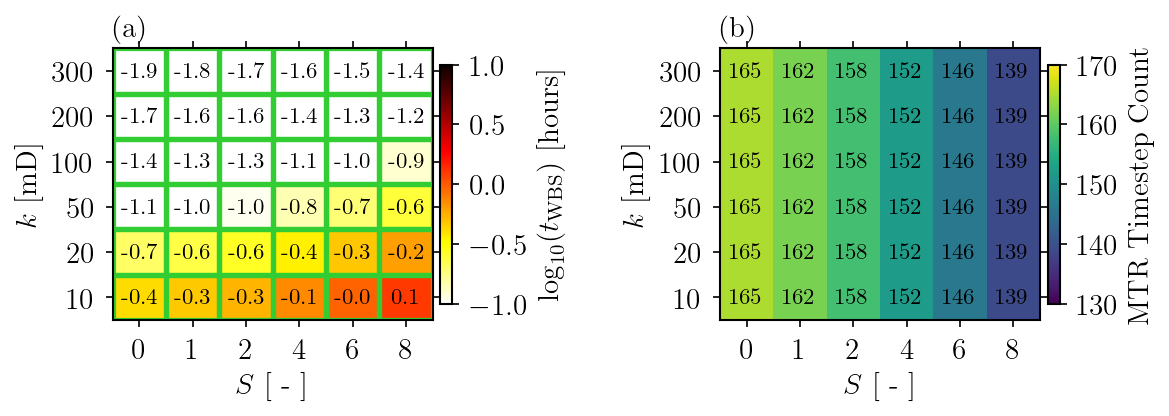

Valid pairs (36): [(10, 0), (10, 1), (10, 2), (10, 4), (10, 6), (10, 8), (20, 0), (20, 1), (20, 2), (20, 4), (20, 6), (20, 8), (50, 0), (50, 1), (50, 2), (50, 4), (50, 6), (50, 8), (100, 0), (100, 1), (100, 2), (100, 4), (100, 6), (100, 8), (200, 0), (200, 1), (200, 2), (200, 4), (200, 6), (200, 8), (300, 0), (300, 1), (300, 2), (300, 4), (300, 6), (300, 8)]


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

t_wbs_mat = np.array([[170000*C_WBS*MU_CP*np.exp(0.14*s)/(k*H_FT)
                        for s in S_GRID] for k in K_GRID])
ax = axes[0]
log_tw = np.log10(np.clip(t_wbs_mat, 1e-3, 1e10))
im = ax.imshow(log_tw, aspect="auto", cmap="hot_r", origin="lower", vmin=-1, vmax=1)
ax.set_xticks(range(len(S_GRID))); ax.set_xticklabels(S_GRID)
ax.set_yticks(range(len(K_GRID))); ax.set_yticklabels(K_GRID)
ax.set_xlabel("$S$ [ - ]"); ax.set_ylabel("$k$ [mD]")
ax.set_title("(a)", loc = 'left',  fontsize = 12, font = 'normal', pad=6)
for i, k in enumerate(K_GRID):
    for j, s in enumerate(S_GRID):
        valid, *_ = physics_screen(k, s)
        ec = "limegreen"; lw_ec = 2.5
        if not valid:
            ax.add_patch(plt.Rectangle((j-0.5,i-0.5),1,1,fill=True,
                         facecolor="black",alpha=0.30,edgecolor="grey",linewidth=0.8))
            ec = "grey"; lw_ec = 0.8
        ax.add_patch(plt.Rectangle((j-0.5,i-0.5),1,1,fill=False,
                     edgecolor=ec,linewidth=lw_ec))
        v   = log_tw[i,j]
        col = "white" if v > 5 else "black"
        ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=11, font = 'normal', color=col)
cb1 = plt.colorbar(im, ax=ax, shrink=0.88, pad=0.02)
cb1.set_label(r"$\log_{10}(t_{\mathrm{WBS}})$ [hours]")

n_mtr_mat = np.zeros((len(K_GRID),len(S_GRID)))
for i,k in enumerate(K_GRID):
    for j,s in enumerate(S_GRID):
        _,_,_,_,nm,_,_ = physics_screen(k,s)
        n_mtr_mat[i,j] = nm

ax2 = axes[1]
im2 = ax2.imshow(n_mtr_mat, aspect="auto", cmap="viridis", origin="lower", vmin=130, vmax=170)
ax2.set_xticks(range(len(S_GRID))); ax2.set_xticklabels(S_GRID)
ax2.set_yticks(range(len(K_GRID))); ax2.set_yticklabels(K_GRID)
ax2.set_xlabel("$S$ [ - ]"); ax2.set_ylabel("$k$ [mD]")
ax2.set_title("(b)", loc = 'left', fontsize = 12, font = 'normal', pad=6)
for i,k in enumerate(K_GRID):
    for j,s in enumerate(S_GRID):
        valid,*_ = physics_screen(k,s)
        nm = n_mtr_mat[i,j]
        if not valid:
            ax2.add_patch(plt.Rectangle((j-0.5,i-0.5),1,1,fill=True,
                          facecolor="red",alpha=0.20,edgecolor="red",linewidth=0.5))
        col = "black" if nm > 120 else "red"
        ax2.text(j, i, f"{int(nm)}", ha="center", va="center", fontsize=11, font = 'normal',  color=col)
cb2 = plt.colorbar(im2, ax=ax2, shrink=0.88, pad=0.02)
cb2.set_label("MTR Timestep Count")

plt.tight_layout(w_pad=2.0)
#plt.savefig(FIG_DIR / "fig01_parameter_screening.pdf", bbox_inches="tight")
#sf('fig01_sr_rom_parameter_screening.pdf')
plt.show()
print(f"Valid pairs ({len(VALID_PAIRS)}): {VALID_PAIRS}")


### 1.3 File Integrity Check

Verify all valid (k, S, schedule) triples have complete output files with correct dimensions.

In [4]:
issues = []
for k, s in VALID_PAIRS:
    for sid in SCHEDS:
        name = f"k{k:03d}_s{s:02d}_sched{sid}"
        cd   = TRAINING_DIR / name
        sp   = cd / "snapshots_psia.mat"
        if not sp.exists():
            issues.append((name, "snapshots_psia.mat missing")); continue
        try:
            X = load_mat(sp, "X_psia")
            if X.shape[0] != N_CELLS:
                issues.append((name, f"wrong rows {X.shape[0]}"))
            if not np.isfinite(X).all():
                issues.append((name, "NaN/Inf in snapshots"))
        except Exception as e:
            issues.append((name, str(e))); continue
        for fname in ["well_data.mat", "params.json"]:
            if not (cd / fname).exists():
                issues.append((name, f"{fname} missing"))

total = len(VALID_PAIRS) * len(SCHEDS)
print(f"Checked {total} (case, schedule) pairs across {len(VALID_PAIRS)} valid (k,S) points")
if issues:
    print(f"Issues found ({len(issues)}):")
    for nm, msg in issues[:20]:
        print(f"  {nm}: {msg}")
else:
    print("All files present, correct dimensions, no NaN/Inf.")


Checked 252 (case, schedule) pairs across 36 valid (k,S) points
All files present, correct dimensions, no NaN/Inf.


## 2. POD Basis Construction




In [5]:
snap_cols  = []
cases_pod  = []

for k, s in VALID_PAIRS:
    for sid in SCHEDS:  # <-- CHANGED: Loop over all schedules
        name = f"k{k:03d}_s{s:02d}_sched{sid}"
        cd   = TRAINING_DIR / name
        try:
            # 1. Load pressure snapshots
            X  = load_mat(cd / "snapshots_psia.mat", "X_psia")
            dX = X - P_INIT
            
            # 2. Load time data to compute time-step weights
            _, t, _, _, _ = load_well_data(cd)
            
            # 3. Compute dt and apply square-root weighting
            dt = np.diff(t, prepend=0.0)
            dt[0] = t[0]
            w = np.sqrt(dt)
            w /= (w.mean() + 1e-12) # Normalize to avoid SVD scaling issues
            
            # Broadcast the weight across all reservoir cells
            dX_weighted = dX * w 
            
            snap_cols.append(dX_weighted)
            cases_pod.append(name)
            
        except FileNotFoundError:
            print(f"  Missing: {name}")

Z = np.hstack(snap_cols)
print(f"Snapshot matrix Z : {Z.shape}  ({Z.nbytes/1e6:.0f} MB)")
print(f"Cases             : {len(cases_pod)}")
print("Computing SVD ...")
U, sigma, _ = np.linalg.svd(Z, full_matrices=False)
print(f"Done.  sigma[0]={sigma[0]:.2f}  sigma[-1]={sigma[-1]:.2e}")


Snapshot matrix Z : (2500, 88200)  (1764 MB)
Cases             : 252
Computing SVD ...
Done.  sigma[0]=2245963.70  sigma[-1]=2.04e-11


### 2.1 Singular Value Decay and Mode Selection

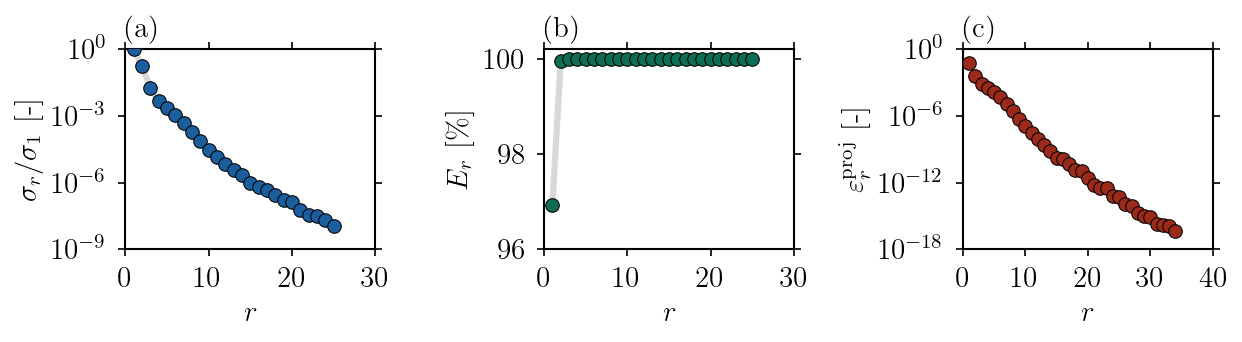

Modes for 99.9% energy      : 2
Modes for proj error < 1e-4 : 6


In [6]:
n_try_range = np.arange(1, min(35, len(sigma)+1))
proj_errors = []
for n_try in n_try_range:
    Vt  = U[:, :n_try]
    err = 0.0
    for k, s in VALID_PAIRS:
        try:
            X  = load_mat(TRAINING_DIR / f"k{k:03d}_s{s:02d}_sched1"
                          / "snapshots_psia.mat", "X_psia") - P_INIT
            Xr = Vt @ (Vt.T @ X)
            err += np.linalg.norm(X-Xr,"fro")**2 / np.linalg.norm(X,"fro")**2
        except FileNotFoundError:
            pass
    proj_errors.append(err / len(VALID_PAIRS))
proj_errors  = np.array(proj_errors)
cum_energy   = np.cumsum(sigma**2) / np.sum(sigma**2)

N_SHOW = min(25, len(n_try_range))
fig, axes = plt.subplots(1, 3, figsize=(8.5, 2.5))

# --- Plot (a): Singular Value Decay ---
ax0 = axes[0]
ax0.semilogy(range(1, N_SHOW+1), sigma[:N_SHOW]/sigma[0], 'o', color=C1, ms=6.5, mec='k', mew=0.5, zorder=3)
ax0.semilogy(range(1, N_SHOW+1), sigma[:N_SHOW]/sigma[0], color='gray', alpha=0.3, lw=3, zorder=1)

ax0.set_title('(a)', loc='left', fontweight='normal')
ax0.set_xlabel('$r$')
ax0.set_ylabel(r'$\sigma_r / \sigma_1$ [-]')
ax0.set_xlim([0, 30])
ax0.set_xticks([0, 10, 20, 30])
ax0.set_ylim([1e-9, 1])

# --- Plot (b): Cumulative Energy ---
ax1 = axes[1]
ax1.plot(range(1, N_SHOW+1), cum_energy[:N_SHOW]*100, 'o', color=C2, ms=6.5, mec='k', mew=0.5, zorder=3)
ax1.plot(range(1, N_SHOW+1), cum_energy[:N_SHOW]*100, color='gray', alpha=0.3, lw=3, zorder=1)

ax1.set_title('(b)', loc='left', fontweight='normal')
ax1.set_xlabel('$r$')
ax1.set_ylabel(r'$E_r \ [\%]$')
ax1.set_xlim([0, 30])
ax1.set_xticks([0, 10, 20, 30])
ax1.set_ylim([96, 100.2])

# --- Plot (c): Mean Projection Error ---
ax2 = axes[2]
ax2.semilogy(n_try_range, proj_errors, 'o', color=C3, ms=6.5, mec='k', mew=0.5, zorder=3)
ax2.semilogy(n_try_range, proj_errors, color='gray', alpha=0.3, lw=3, zorder=1)

ax2.set_title('(c)', loc='left', fontweight='normal')
ax2.set_xlabel('$r$')
ax2.set_ylabel(r'$\varepsilon_r^\mathrm{proj}$ [-]')
ax2.set_xlim([0, 40])
ax2.set_xticks([0, 10, 20, 30, 40])
ax2.set_ylim([1e-18, 1])

plt.tight_layout()
#sf("ch7_1_rom_pod_rank.pdf")
plt.show()

n99  = int(np.argmax(cum_energy >= 0.999)) + 1
n1e4 = int(np.argmax(proj_errors < 1e-4))  + 1 if np.any(proj_errors < 1e-4) else "not reached"
print(f"Modes for 99.9% energy      : {n99}")
print(f"Modes for proj error < 1e-4 : {n1e4}")

### 2.2 Basis Orthogonality Check, Spatial Modes and Save

N_MODES selected : 15
Vn shape         : (2500, 15)
Orthogonality    : ||VnT Vn - I||_inf = 1.11e-15
Proj error mean  : 1.75e-10
Proj error max   : 1.36e-09


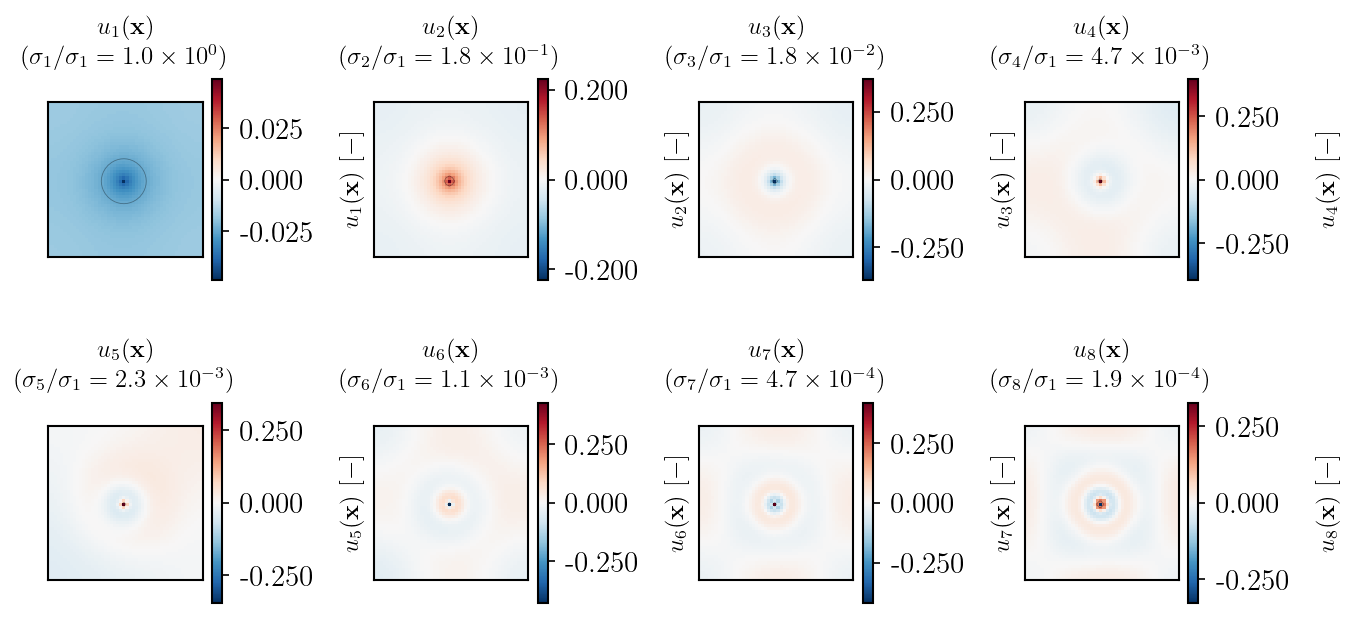

Basis saved to ..\romshift\basis/


In [7]:
N_MODES = 15

Vn       = U[:, :N_MODES]
per_err  = []

for k, s in VALID_PAIRS:
    for sid in SCHEDS:  # <-- CHANGED: Evaluate across all schedules
        try:
            X  = load_mat(TRAINING_DIR / f"k{k:03d}_s{s:02d}_sched{sid}"
                          / "snapshots_psia.mat", "X_psia") - P_INIT
            
            # Note: We evaluate the error on the UNWEIGHTED snapshots (X)
            # because we want to measure the physical pressure error.
            Xr = Vn @ (Vn.T @ X)
            per_err.append(np.linalg.norm(X-Xr,"fro")**2 / np.linalg.norm(X,"fro")**2)
        except FileNotFoundError:
            pass

print(f"N_MODES selected : {N_MODES}")
print(f"Vn shape         : {Vn.shape}")
print(f"Orthogonality    : ||VnT Vn - I||_inf = {np.abs(Vn.T@Vn - np.eye(N_MODES)).max():.2e}")
print(f"Proj error mean  : {np.mean(per_err):.2e}")
print(f"Proj error max   : {np.max(per_err):.2e}")

# ---------------------------------------------------------
# Spatial modes figure (Updated Formatting)
# ---------------------------------------------------------
n_show = min(N_MODES, 8)
fig, axes = plt.subplots(2, 4, figsize=(9, 4.5))

for i in range(n_show):
    ax   = axes[i//4, i%4]
    ui   = U[:, i].reshape(NY, NX)
    vm   = np.abs(ui).max()
    
    im   = ax.imshow(ui, origin="lower", cmap="RdBu_r", vmin=-vm, vmax=vm, aspect="equal")
    
    # 1. Add the contour line representing 50% max amplitude
    ax.contour(np.abs(ui), levels=[vm*0.5], colors=['k'], linewidths=0.4, alpha=0.35)
    
    # 2. Extract and format the scientific notation for the title
    ratio = sigma[i] / sigma[0]
    m_val = f"{ratio:.1e}".split('e')[0]
    e_val = int(f"{ratio:.1e}".split('e')[1])
    
    # 3. Apply standard title format
    ax.set_title(f'${{u}}_{{{i+1}}}(\\mathbf{{x}})$\n'
                 f'$(\\sigma_{{{i+1}}}/\\sigma_1={m_val} \\times 10^{{{e_val}}})$\n',
                 fontsize=12)
    
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
    
    # 4. Standard colorbar with label
    cb = plt.colorbar(im, ax=ax, shrink=0.88, format='%.3f')
    cb.set_label(rf'$u_{{{i+1}}}(\mathbf{{x}})\ [-]$', fontsize=12, rotation=90, labelpad=12)
plt.tight_layout(w_pad=0.5, h_pad=1.5)
#sf("ch7_2_rom_pod_spatial.pdf")
plt.show()

# ---------------------------------------------------------
# Save Basis and Metadata
# ---------------------------------------------------------
np.save(ROM_DIR / "basis" / "Vn.npy", Vn)
np.save(ROM_DIR / "basis" / "sigma.npy", sigma)
basis_meta = dict(n_modes=int(N_MODES), N_cells=int(N_CELLS),
                  p_init_psia=float(P_INIT),
                  proj_error_mean=float(np.mean(per_err)),
                  proj_error_max=float(np.max(per_err)),
                  valid_pairs=[[int(k),int(s)] for k,s in VALID_PAIRS])
with open(ROM_DIR/"basis"/"basis_meta.json","w") as f:
    json.dump(basis_meta, f, indent=2)
print(f"Basis saved to {ROM_DIR/'basis'}/")

## 3. Operator Inference



In [8]:
def infer_AB(Vn, X_list, U_list, T_list, x0_list, t_wbs_list, lam_mult=1.0):
    n_r = Vn.shape[1]
    Xhat_rows, U_rows, R_rows, W_rows = [], [], [], []
    for X, u, t, x0, t_wbs in zip(X_list, U_list, T_list, x0_list, t_wbs_list):
        dX    = X - P_INIT
        Xhat  = (Vn.T @ dX).T
        dt    = np.diff(t, prepend=0.0); dt[0] = t[0]
        R     = np.zeros_like(Xhat)
        R[0]  = Xhat[0] / dt[0]
        for j in range(1, len(t)):
            R[j] = (Xhat[j] - Xhat[j-1]) / dt[j]
        i_s = 1
        w   = np.sqrt(dt[i_s:]); w /= (w.mean() + 1e-12)
        Xhat_rows.append(Xhat[i_s:])
        U_rows.append(u[i_s:].reshape(-1,1))
        R_rows.append(R[i_s:])
        W_rows.append(w)
    Xhat_all = np.vstack(Xhat_rows); U_all = np.vstack(U_rows)
    R_all    = np.vstack(R_rows);    W_all = np.concatenate(W_rows)
    D        = np.hstack([Xhat_all, U_all])
    cond_D   = np.linalg.cond(D)
    col_norms = np.linalg.norm(D, axis=0) + 1e-12
    D_w = (D / col_norms) * W_all[:, None]
    R_w = R_all * W_all[:, None]
    
    # --- ADAPTIVE LAMBDA MULTIPLIER APPLIED HERE ---
    lam    = 1e-6 * lam_mult * np.trace(D_w.T @ D_w) / D_w.shape[1]
    
    nc     = D_w.shape[1]
    D_aug  = np.vstack([D_w, np.sqrt(lam)*np.eye(nc)])
    R_aug  = np.vstack([R_w, np.zeros((nc, n_r))])
    OT_sc, *_ = np.linalg.lstsq(D_aug, R_aug, rcond=None)
    OT = OT_sc / col_norms[:, None]
    O  = OT.T
    return O[:, :n_r], O[:, n_r:n_r+1], cond_D


def infer_CD(Vn, X_list, U_list, BHP_list, T_list, t_wbs_list):
    # 1. EXACT C_hat: The observation matrix is simply the well-cell row of the basis!
    C_hat = Vn[WC_IDX, :].reshape(1, -1)
    
    # 2. ROBUST ALGEBRAIC D_hat: Use scalar least-squares to avoid division by zero
    D_estimates = []
    for X, u, bhp in zip(X_list, U_list, BHP_list):
        dX = X - P_INIT
        Xhat = (Vn.T @ dX).T
        dU = u.reshape(-1, 1)
        dBHP = (bhp - P_INIT).reshape(-1, 1)
        
        # Calculate grid block pressure drop
        grid_pressure_drop = (C_hat @ Xhat.T).T
        
        # Calculate pure skin effect
        skin_drop = dBHP[1:] - grid_pressure_drop[1:]
        
        # ROBUST D CALCULATION: scalar least squares (u^T u)^-1 u^T y
        # This completely avoids division by zero if the well rate is 0
        u_vec = dU[1:]
        num = np.vdot(u_vec, skin_drop)
        den = np.vdot(u_vec, u_vec) + 1e-12  # 1e-12 prevents pure zero division
        
        D_estimates.append(num / den)
        
    # Average the D estimate for this specific (k, S) pair
    D_hat = np.array([[np.mean(D_estimates)]])
    
    return C_hat, D_hat

print("Operator inference functions defined.")

Operator inference functions defined.


### 3.2 Run Inference Over All Valid Parameter Points

In [24]:
ops_dir = ROM_DIR / "operators"
if ops_dir.exists():
    shutil.rmtree(ops_dir)
ops_dir.mkdir(parents=True)
print("Cleared rom/operators/ — running fresh inference")

results = []
for k, s in VALID_PAIRS:
    tag     = f"k{k:03d}_s{s:02d}"
    out_dir = ops_dir / tag;  out_dir.mkdir(exist_ok=True)

    X_list, U_list, T_list, BHP_list, t_wbs_list, scheds_ok = [], [], [], [], [], []
    _, t_wbs_an, *_ = physics_screen(k, s)

    for sid in SCHEDS:
        cd = TRAINING_DIR / f"k{k:03d}_s{s:02d}_sched{sid}"
        try:
            X            = load_mat(cd/"snapshots_psia.mat","X_psia")
            bhp, t, q, _, pm = load_well_data(cd)
            t_wbs_case   = float(pm["t_wbs_end_hr"])
            if t_wbs_case >= t[-1]:
                continue
            X_list.append(X); U_list.append(q); T_list.append(t)
            BHP_list.append(bhp); t_wbs_list.append(t_wbs_case)
            scheds_ok.append(sid)
        except FileNotFoundError:
            pass

    if not X_list:
        print(f"  SKIP {tag}"); continue
    

    # --- NEW ADAPTIVE REGULARIZATION LOOP ---
    max_attempts = 6
    lam_mult = 1.0
    stable = False
    stabilised = False
    stability_tol = 1e-5  # The floating-point noise tolerance
    
    for attempt in range(max_attempts):
        # Pass the current lam_mult to the infer_AB function
        A_hat, B_hat, cond_D = infer_AB(Vn, X_list, U_list, T_list,
                                         [np.zeros(N_CELLS)]*len(X_list), t_wbs_list, lam_mult=lam_mult)
        
        eigv, _ = np.linalg.eig(A_hat)
        
        # Check stability against the tolerance
        if np.any(eigv.real > stability_tol):
            # Model is unstable. Multiply penalty by 10 and try again.
            lam_mult *= 10.0
        else:
            # Model is stable!
            stable = True
            stabilised = (attempt > 0) # Marks True if it needed extra regularization
            max_rf = float(eigv.real.max())
            break # Exit the retry loop
    else:
        # This triggers only if it fails all attempts
        max_rf = float(eigv.real.max())
        print(f"  Warning: {tag} remained unstable despite high regularization.")
        if not stable:
            shift  = float(eigv.real.max()) + 1e-6
            A_hat  = A_hat - shift * np.eye(A_hat.shape[0])
            eigv   = np.linalg.eigvals(A_hat)
            if np.all(eigv.real < 0):
                stable     = True
                stabilised = True
                max_rf     = float(eigv.real.max())
                print(f"  Stabilised via shift of {shift:.6f} hr^-1")

    # Infer C (not impacted by dynamic stability)
    # Infer C and D (incorporating Direct Feedthrough)
    C_hat, D_hat = infer_CD(Vn, X_list, U_list, BHP_list, T_list, t_wbs_list)

    print(f"Case {tag} D_hat: {D_hat[0,0]:.4f}")

    # --- SAVE MATRICES ---
    np.save(out_dir/"A_hat.npy", A_hat)
    np.save(out_dir/"B_hat.npy", B_hat)
    np.save(out_dir/"C_hat.npy", C_hat)
    np.save(out_dir/"D_hat.npy", D_hat) # Save the new D matrix

    rep = dict(tag=tag, k=k, S=s, n_scheds=len(scheds_ok),
               cond_D=float(cond_D), max_eig=float(max_rf),
               stabilised=stabilised, stable=stable,
               eig_real=eigv.real.tolist(), eig_imag=eigv.imag.tolist())
    with open(out_dir/"report.json","w") as f:
        json.dump(rep, f, indent=2)
    results.append(rep)

    flag = "" if stable else " !UNSTABLE"
    sb   = " [stabilised]" if stabilised else ""
    print(f"  {tag}  n={len(scheds_ok)}  cond={cond_D:.1e}  max_eig={max_rf:.4f}{flag}{sb}")

df_ops = pd.DataFrame(results)
print(f"\nInferred : {len(results)}/{len(VALID_PAIRS)}")
print(f"Stable   : {df_ops['stable'].sum()}/{len(results)}")
print(f"cond(D) median : {df_ops['cond_D'].median():.2e}")

Cleared rom/operators/ — running fresh inference
Case k010_s00 D_hat: -0.4550
  k010_s00  n=7  cond=4.3e+05  max_eig=0.0000
Case k010_s01 D_hat: -0.5682
  k010_s01  n=7  cond=4.3e+05  max_eig=0.0000
Case k010_s02 D_hat: -0.6815
  k010_s02  n=7  cond=4.3e+05  max_eig=0.0000
Case k010_s04 D_hat: -0.9079
  k010_s04  n=7  cond=4.3e+05  max_eig=0.0000
Case k010_s06 D_hat: -1.1343
  k010_s06  n=7  cond=4.3e+05  max_eig=0.0000
Case k010_s08 D_hat: -1.3607
  k010_s08  n=7  cond=4.3e+05  max_eig=0.0000
Case k020_s00 D_hat: -0.2273
  k020_s00  n=7  cond=3.5e+05  max_eig=0.0000
Case k020_s01 D_hat: -0.2839
  k020_s01  n=7  cond=3.5e+05  max_eig=0.0000
Case k020_s02 D_hat: -0.3404
  k020_s02  n=7  cond=3.5e+05  max_eig=0.0000
Case k020_s04 D_hat: -0.4535
  k020_s04  n=7  cond=3.5e+05  max_eig=0.0000
Case k020_s06 D_hat: -0.5666
  k020_s06  n=7  cond=3.5e+05  max_eig=0.0000
Case k020_s08 D_hat: -0.6797
  k020_s08  n=7  cond=3.5e+05  max_eig=0.0000
Case k050_s00 D_hat: -0.0909
  k050_s00  n=7  cond=

### 3.3 Condition Number and Eigenvalue Analysis

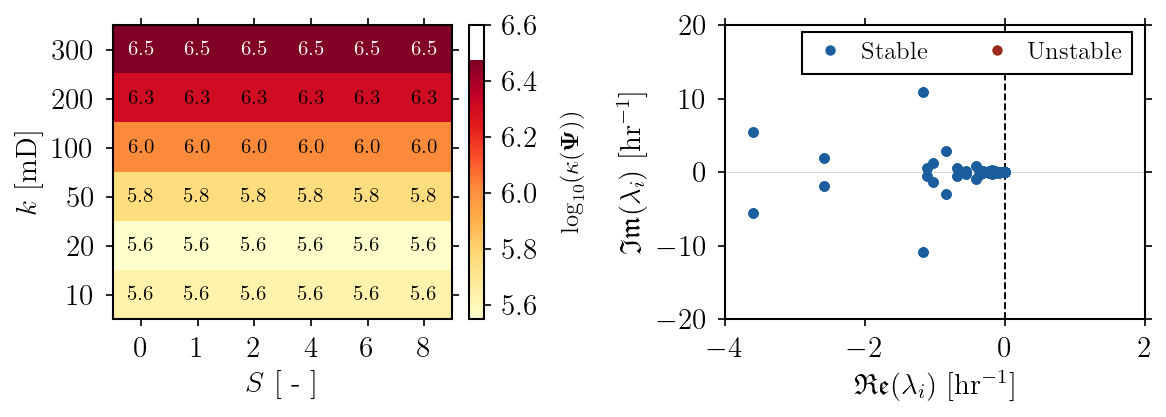

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

cond_mat = np.full((len(K_GRID), len(S_GRID)), np.nan)
for rep in results:
    i = K_GRID.index(rep["k"]); j = S_GRID.index(rep["S"])
    cond_mat[i, j] = np.log10(rep["cond_D"])

ax = axes[0]
masked = np.ma.masked_invalid(cond_mat)
im = ax.imshow(masked, aspect="auto", cmap="YlOrRd", origin="lower")
ax.set_xticks(range(len(S_GRID))); ax.set_xticklabels(S_GRID)
ax.set_yticks(range(len(K_GRID))); ax.set_yticklabels(K_GRID)
ax.set_xlabel("$S$ [ - ]"); ax.set_ylabel("$k$ [mD]")
#ax.set_title(r"(a)  $\log_{10}\,\kappa(\mathbf{D})$", pad=6)
for i in range(len(K_GRID)):
    for j in range(len(S_GRID)):
        if not np.isnan(cond_mat[i,j]):
            v   = cond_mat[i,j]
            col = "white" if v > np.nanmedian(cond_mat)+0.5 else "black"
            ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=10, color=col)
        else:
            ax.add_patch(plt.Rectangle((j-0.5,i-0.5),1,1,fill=True,
                         facecolor="lightgrey",alpha=0.6,edgecolor="grey",linewidth=0.5))
            ax.text(j, i, "—", ha="center", va="center", fontsize=12, color="grey")
cb = plt.colorbar(im, ax=ax, shrink=1, pad=0.04)
cb.set_label(r"$\log_{10}(\kappa(\mathbf{\Psi}))$", fontsize=12, fontweight='normal', labelpad=10)
cb.set_ticks([5.6,5.8,6.0, 6.2, 6.4, 6.6])
ax2 = axes[1]
for rep in results:
    col = C1 if rep["stable"] else C3
    ax2.scatter(rep["eig_real"], rep["eig_imag"],
                s=25, color=col, alpha=0.55, linewidths=0, zorder=3)
ax2.axvline(0, color="k", lw=0.9, ls="--", zorder=2, label="Stability boundary")
ax2.axhline(0, color="grey", lw=0.4, alpha=0.4)
ax2.set_xlabel(r"$\mathfrak{Re}(\lambda_i)$ [hr$^{-1}$]")
ax2.set_ylabel(r"$\mathfrak{Im}(\lambda_i)$ [hr$^{-1}$]")
ax2.set_xlim([-4,2])
ax2.set_ylim([-20,20])
#ax2.set_title(r"(b)  Eigenvalue spectrum of $\hat{A}$", pad=6)
leg = [Line2D([0],[0],marker="o",color="w",markerfacecolor=C1,markersize=6,label="Stable"),
       Line2D([0],[0],marker="o",color="w",markerfacecolor=C3,markersize=6,label="Unstable")]
ax2.legend(handles=leg, loc='upper right', bbox_to_anchor=(1, 1.02), fontsize=12, ncol=2, frameon=True)


plt.tight_layout()
#sf("ch7_3_rom_stability_check.pdf")
plt.show()


### 3.4 Self-Reconstruction Check

Pressure drawdown and first apmpitude of rom latent variable plotted against time. The time series is computed using integration in ROM 

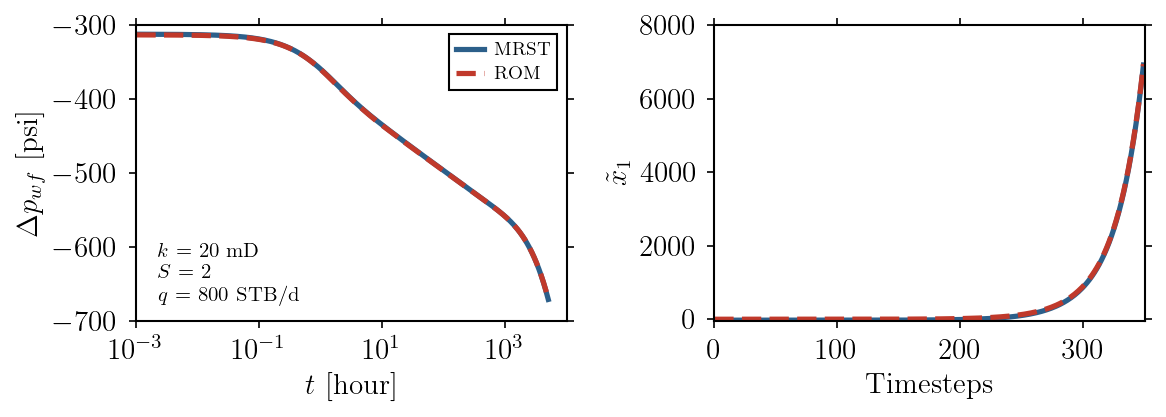

State error  : 1.96e-02  (target < 0.05)
Output error : 1.31e-03  (target < 0.10)


In [26]:
def integrate_rom(A, B, C, D, t_hr, q_vec, n): # Added D to arguments
    K  = len(t_hr)
    dt = np.diff(t_hr, prepend=0.0); dt[0] = t_hr[0]
    In = np.eye(n); xk = np.zeros(n)
    Xr = np.zeros((K, n)); Yr = np.zeros(K)
    for j in range(K):
        # State update (Backward Euler) remains the same
        rhs  = xk + dt[j]*B.ravel()*q_vec[j]
        xk   = np.linalg.solve(In - dt[j]*A, rhs)
        
        # Output equation NOW includes D * u
        Xr[j] = xk
        Yr[j] = float(C @ xk + D * q_vec[j]) # Direct feedthrough added here
        
    return Xr, Yr

k_chk, s_chk, sid_chk = 20, 2, 1
tag_chk = f"k{k_chk:03d}_s{s_chk:02d}"

# 1. Load all FOUR operators (A, B, C, and the new D)
A_c = np.load(ops_dir/tag_chk/"A_hat.npy")
B_c = np.load(ops_dir/tag_chk/"B_hat.npy")
C_c = np.load(ops_dir/tag_chk/"C_hat.npy")
D_c = np.load(ops_dir/tag_chk/"D_hat.npy") # <-- ADDED THIS LINE

cd  = TRAINING_DIR / f"{tag_chk}_sched{sid_chk}"
X_f = load_mat(cd/"snapshots_psia.mat","X_psia")
bhp_f, t_hr, q_v, _, _ = load_well_data(cd)

Xhat_f = (Vn.T @ (X_f - P_INIT)).T
dBHP_f = bhp_f - P_INIT

# 2. Pass D_c into the function call
Xr, Yr = integrate_rom(A_c, B_c, C_c, D_c, t_hr, q_v, N_MODES) 

state_err  = (np.linalg.norm(Xr-Xhat_f,"fro") / np.linalg.norm(Xhat_f,"fro"))
output_err = (np.linalg.norm(Yr-dBHP_f) / np.linalg.norm(dBHP_f))

info_text = (f"$k$ = {k_chk} mD\n"
             f"$S$ = {s_chk}\n"
             "$q$ = 800 STB/d")

fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].semilogx(t_hr, dBHP_f, lw=2.5, color=C_MRST, label="MRST")
axes[0].text(0.05, 0.05, info_text, 
             transform=axes[0].transAxes, 
             fontsize=10, 
             verticalalignment="bottom")
axes[0].semilogx(t_hr, Yr,     lw=2.5, color=C_ROM, ls="--", label="ROM")
axes[0].set_xlabel("$t$ [hour]"); axes[0].set_ylabel(r"$\Delta p_{wf}$ [psi]")
axes[0].set_xlim([1e-3, 1e4])
axes[0].set_ylim([-700, -300])
axes[0].xaxis.set_minor_locator(NullLocator())
axes[0].yaxis.set_minor_locator(NullLocator())
#axes[0].set_title(f"BHP self-reconstruction — {tag_chk}, sched {sid_chk}")
axes[0].legend(fontsize=9)
axes[1].plot(Xhat_f[:,0], lw=2.5, color=C_MRST, label="MRST")
axes[1].plot(Xr[:,0],     lw=2.5, color=C_ROM, ls="--", label="ROM")
axes[1].set_xlabel("Timesteps"); axes[1].set_ylabel(r"$\tilde{x}_1$")
axes[1].set_xlim([0, 350])
axes[1].set_ylim([-50, 8000])
#axes[1].set_title("First POD mode coefficient"); axes[1].legend(fontsize=9)
plt.tight_layout()
#sf("fig05_self_recon.pdf")
plt.show()
print(f"State error  : {state_err:.2e}  (target < 0.05)")
print(f"Output error : {output_err:.2e}  (target < 0.10)")


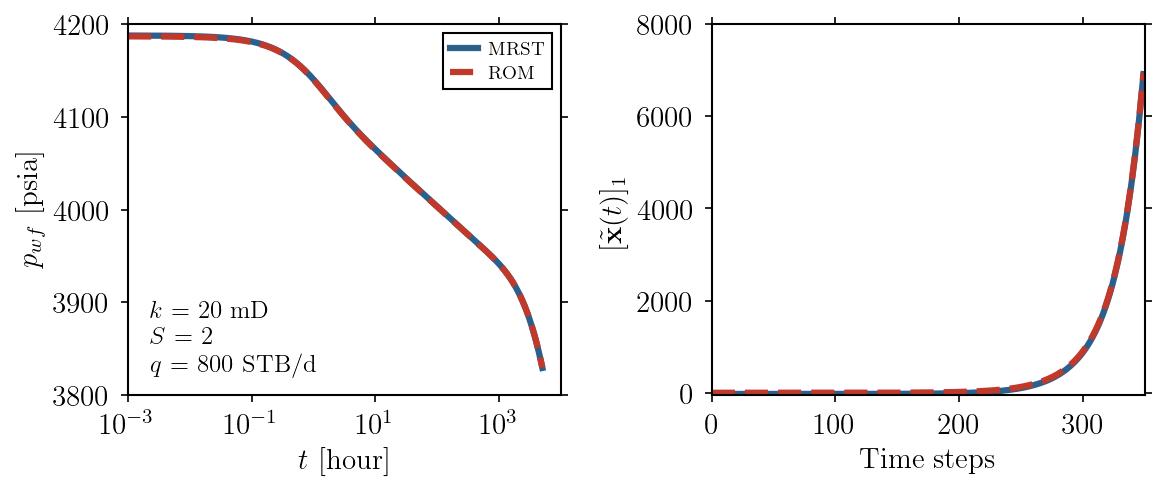

State error  : 1.96e-02  (target < 0.05)
Output error : 1.31e-03  (target < 0.10)


In [27]:
def integrate_rom(A, B, C, D, t_hr, q_vec, n):
    K  = len(t_hr)
    dt = np.diff(t_hr, prepend=0.0); dt[0] = t_hr[0]
    In = np.eye(n); xk = np.zeros(n)
    Xr = np.zeros((K, n)); Yr = np.zeros(K)
    for j in range(K):
        rhs  = xk + dt[j]*B.ravel()*q_vec[j]
        xk   = np.linalg.solve(In - dt[j]*A, rhs)
        Xr[j] = xk
        Yr[j] = float(C @ xk + D * q_vec[j])
    return Xr, Yr

k_chk, s_chk, sid_chk = 20, 2, 1
tag_chk = f"k{k_chk:03d}_s{s_chk:02d}"

A_c = np.load(ops_dir/tag_chk/"A_hat.npy")
B_c = np.load(ops_dir/tag_chk/"B_hat.npy")
C_c = np.load(ops_dir/tag_chk/"C_hat.npy")
D_c = np.load(ops_dir/tag_chk/"D_hat.npy")

cd     = TRAINING_DIR / f"{tag_chk}_sched{sid_chk}"
X_f    = load_mat(cd/"snapshots_psia.mat", "X_psia")
bhp_f, t_hr, q_v, _, _ = load_well_data(cd)

Xhat_f = (Vn.T @ (X_f - P_INIT)).T
dBHP_f = bhp_f - P_INIT

Xr, Yr = integrate_rom(A_c, B_c, C_c, D_c, t_hr, q_v, N_MODES)

state_err  = np.linalg.norm(Xr - Xhat_f, "fro") / np.linalg.norm(Xhat_f, "fro")
output_err = np.linalg.norm(Yr - dBHP_f)         / np.linalg.norm(dBHP_f)

info_text = (f"$k$ = {k_chk} mD\n"
             f"$S$ = {s_chk}\n"
             f"$q$ = 800 STB/d")

fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))

# Left panel — actual p_wf [psia]
axes[0].semilogx(t_hr, bhp_f,       lw=3, color=C_MRST, label="MRST")
axes[0].semilogx(t_hr, P_INIT + Yr, lw=3, color=C_ROM,  ls="--", label="ROM")
axes[0].text(0.05, 0.05, info_text,
             transform=axes[0].transAxes,
             fontsize=12, verticalalignment="bottom")
axes[0].set_xlabel("$t$ [hour]")
axes[0].set_ylabel("$p_{wf}$ [psia]")
axes[0].set_xlim([1e-3, 1e4])
axes[0].set_ylim([3800, 4200])
axes[0].xaxis.set_minor_locator(NullLocator())
axes[0].yaxis.set_minor_locator(NullLocator())
axes[0].legend(fontsize=9)

# Right panel — first reduced amplitude a_1(t)
axes[1].plot(Xhat_f[:, 0], lw=3, color=C_MRST, label="MRST")
axes[1].plot(Xr[:, 0],     lw=3, color=C_ROM,  ls="--", label="ROM")
axes[1].set_xlabel("Time steps")
axes[1].set_ylabel(r"$[\tilde{\mathbf{x}}(t)]_1$")
axes[1].set_xlim([0, 350])
axes[1].set_ylim([-50, 8000])
axes[1].xaxis.set_minor_locator(NullLocator())
axes[1].yaxis.set_minor_locator(NullLocator())
#axes[1].legend(fontsize=9)

plt.tight_layout()
#sf("ch7_4_rom_self_recon.pdf")
plt.show()

print(f"State error  : {state_err:.2e}  (target < 0.05)")
print(f"Output error : {output_err:.2e}  (target < 0.10)")

## 4. Operator Interpolation



In [28]:
pts_lst = []
# Added D_list2 to store the direct feedthrough operators
A_list2, B_list2, C_list2, D_list2 = [], [], [], []

for rep in results:
    if not rep["stable"]: continue
    
    # Load all four operators for every stable parameter point
    A_list2.append(np.load(ops_dir/rep["tag"]/"A_hat.npy"))
    B_list2.append(np.load(ops_dir/rep["tag"]/"B_hat.npy"))
    C_list2.append(np.load(ops_dir/rep["tag"]/"C_hat.npy"))
    D_list2.append(np.load(ops_dir/rep["tag"]/"D_hat.npy")) # Added D_hat loading
    
    # Use log10 for permeability to ensure smooth interpolation across magnitudes
    pts_lst.append([np.log10(rep["k"]), rep["S"]])

pts   = np.array(pts_lst)
A_arr = np.array(A_list2)
B_arr = np.array(B_list2)
C_arr = np.array(C_list2)
D_arr = np.array(D_list2) # Added D_arr

M = len(pts)
print(f"Interpolation training points : {M}")

# --- THE CRITICAL FIX: FEATURE SCALING ---
# Calculate the min and max for log(k) and S
pts_min = pts.min(axis=0)
pts_max = pts.max(axis=0)
pts_range = pts_max - pts_min
pts_range[pts_range == 0] = 1.0 # Safety check to prevent division by zero

# Normalize training points to strictly [0, 1]
pts_norm = (pts - pts_min) / pts_range

def build_rbf(arr, pts_normalized, smoothing=0.0):
    shape = arr.shape[1:]
    flat  = arr.reshape(len(arr), -1)
    
    # CRITICAL FIX: Use "linear" to guarantee no overshooting/wiggles between points
    ints  = [RBFInterpolator(pts_normalized, flat[:,c],
                             kernel="linear", smoothing=smoothing)
             for c in range(flat.shape[1])]
    return ints, shape

def eval_op(interps, shape, k_q, s_q):
    # 1. Create the query point in log-space
    pt = np.array([[np.log10(k_q), s_q]])
    
    # 2. Normalize the query point using the exact same training bounds
    pt_norm = (pt - pts_min) / pts_range
    
    # 3. Evaluate the RBF on the normalized point
    return np.array([f(pt_norm)[0] for f in interps]).reshape(shape)

# Build the interpolants using the normalized points (pts_norm)
# A tiny bit of smoothing (0.01) on A protects against late-time noise
print("Building A interpolants..."); A_interps, A_shape = build_rbf(A_arr, pts_norm, smoothing=0.01)
print("Building B interpolants..."); B_interps, B_shape = build_rbf(B_arr, pts_norm, smoothing=0.01)
print("Building C interpolants..."); C_interps, C_shape = build_rbf(C_arr, pts_norm, smoothing=0.01)
print("Building D interpolants..."); D_interps, D_shape = build_rbf(D_arr, pts_norm, smoothing=0.01)
print("Done.")

Interpolation training points : 36
Building A interpolants...
Building B interpolants...
Building C interpolants...
Building D interpolants...
Done.


### 4.1 Leave-One-Out Cross-Validation

  fig06_loo.pdf


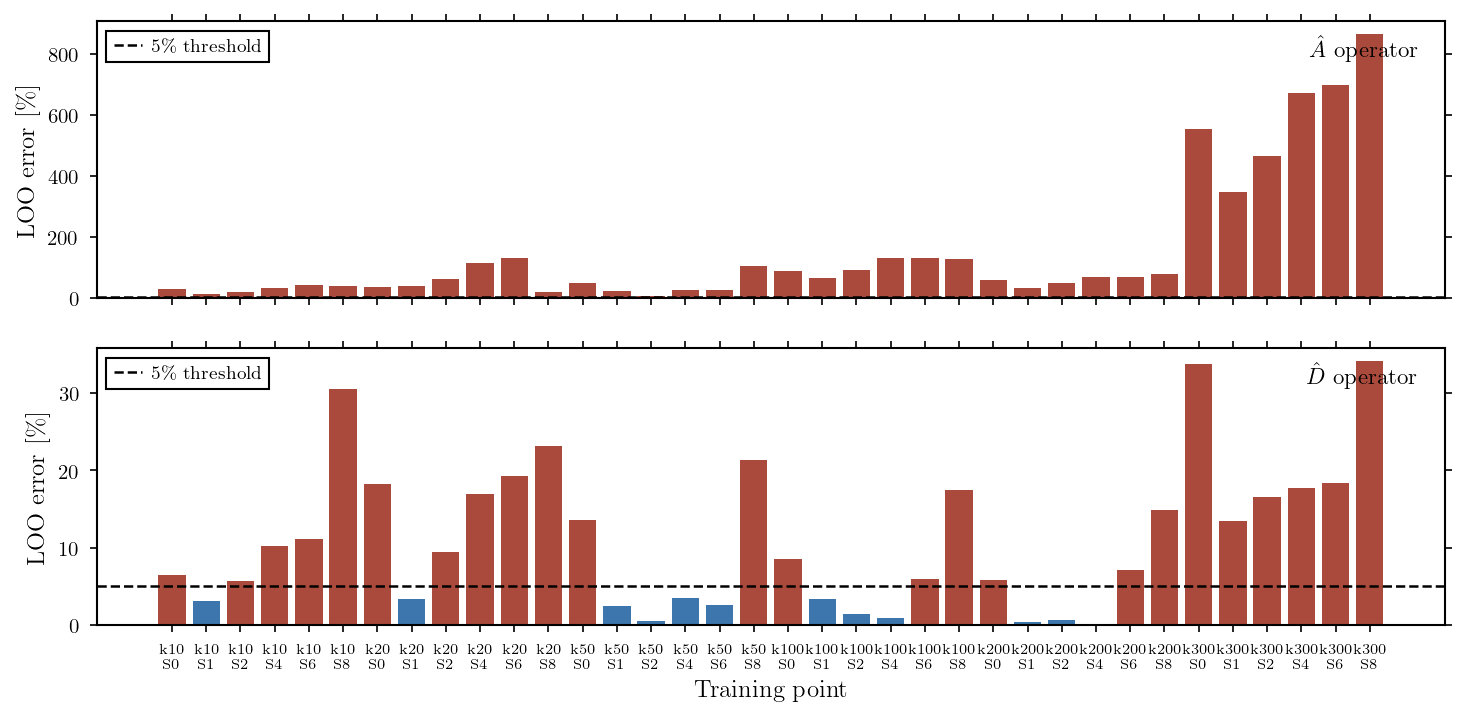

LOO  A: mean = 150.57%   max = 862.80%
LOO  D: mean = 11.17%   max = 34.11%
Points above 5%  A: 36   D: 24
Effective training set: 36 / 36


In [ ]:
# ── §4.1  Leave-One-Out Cross-Validation ──────────────────────────────────

def get_loo_errors(arr, pts_normalized):
    """
    LOO cross-validation on RBF interpolant using normalised coordinates.
    Uses TPS kernel (conservative upper bound on linear-kernel error).
    """
    M     = len(pts_normalized)
    shape = arr.shape[1:]
    flat  = arr.reshape(M, -1)
    errors = []
    for held in range(M):
        mask     = np.arange(M) != held
        pred_flat = np.zeros(flat.shape[1])
        for c in range(flat.shape[1]):
            rbf = RBFInterpolator(pts_normalized[mask], flat[mask, c],
                                  kernel="linear", smoothing=0.0)
            pred_flat[c] = rbf(pts_normalized[[held]])[0]
        actual = arr[held]
        pred   = pred_flat.reshape(shape)
        err    = (np.linalg.norm(actual - pred, "fro") /
                  np.linalg.norm(actual, "fro"))
        errors.append(err)
    return np.array(errors)

# Pass pts_norm (normalised [0,1]^2) to match the production interpolant
errs_A = get_loo_errors(A_arr, pts_norm)
errs_D = get_loo_errors(D_arr, pts_norm)

labels = [f"k{int(r['k'])}\nS{int(r['S'])}"
          for r in results if r["stable"]]

fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

for ax, errs, title in zip(axes,
                            [errs_A * 100, errs_D * 100],
                            [r"$\hat{A}$ operator", r"$\hat{D}$ operator"]):
    bar_cols = [C1 if e < 5.0 else C3 for e in errs]
    ax.bar(range(len(errs)), errs, color=bar_cols, alpha=0.85)
    ax.axhline(5.0, color="k", ls="--", lw=1.2, label="5\% threshold")
    ax.set_ylabel("LOO error [\%]", fontsize=12)
    ax.text(0.98, 0.95, title, transform=ax.transAxes,
            ha="right", va="top", fontsize=11)
    ax.legend(fontsize=9)
    ax.xaxis.set_minor_locator(NullLocator())
    ax.yaxis.set_minor_locator(NullLocator())
    ax.tick_params(labelsize=10)

axes[1].set_xticks(range(len(labels)))
axes[1].set_xticklabels(labels, fontsize=7)
axes[1].set_xlabel("Training point", fontsize=12)

plt.tight_layout()
#sf("fig06_loo.pdf")
plt.show()

print(f"LOO  A: mean = {errs_A.mean()*100:.2f}%   max = {errs_A.max()*100:.2f}%")
print(f"LOO  D: mean = {errs_D.mean()*100:.2f}%   max = {errs_D.max()*100:.2f}%")
print(f"Points above 5%  A: {(errs_A>0.05).sum()}   D: {(errs_D>0.05).sum()}")
print(f"Effective training set: {len(errs_A)} / 36")

### 4.2 Interpolation Surfaces and Save

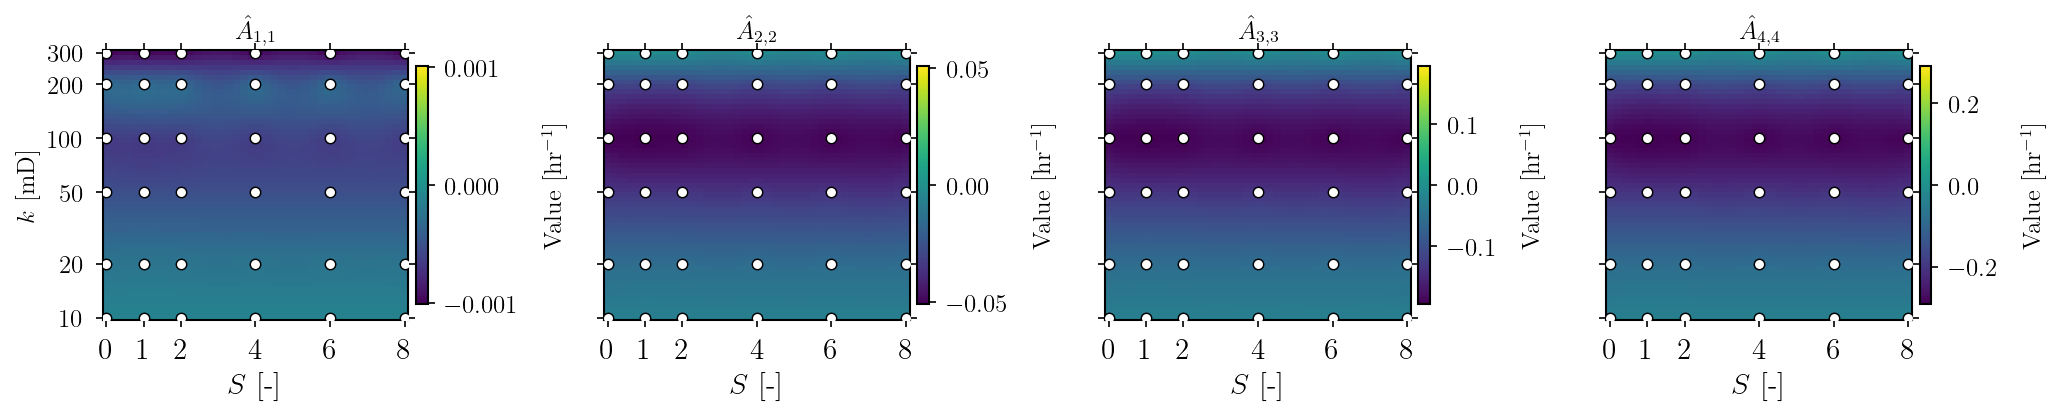

Interpolants and Metadata saved to ..\romshift\interpolants/


In [44]:
# --- Visualization (Axes swapped and colorbar title added) ---
k_fine = np.logspace(np.log10(10), np.log10(300), 55)
s_fine = np.linspace(0, 8, 40)
KK, SS = np.meshgrid(k_fine, s_fine)
n_diag = min(4, N_MODES)
diag   = np.zeros((n_diag, *KK.shape))

for gi in range(KK.shape[0]):
    for gj in range(KK.shape[1]):
        A_q = eval_op(A_interps, A_shape, KK[gi,gj], SS[gi,gj])
        for m in range(n_diag):
            diag[m, gi, gj] = A_q[m, m]

fig, axes = plt.subplots(1, n_diag, figsize=(3.5*n_diag, 3))
for m in range(n_diag):
    ax  = axes[m]
    dat = diag[m]
    lim = np.abs(dat).max()
    
    # 1. SWAPPED AXES: SS is x-axis, np.log10(KK) is y-axis
    im  = ax.pcolormesh(SS, np.log10(KK), dat,
                        cmap="viridis", shading="auto", vmin=-lim, vmax=lim)
    
    valid_k = [k for k,s in VALID_PAIRS]
    valid_s = [s for k,s in VALID_PAIRS]
    
    # 2. SWAPPED AXES: valid_s is x-axis, np.log10(k) is y-axis
    ax.scatter(valid_s, [np.log10(k) for k in valid_k],
               c="white", s=25, edgecolors="k", linewidths=0.7, zorder=5)
               
    # 3. Formatting X-axis (Skin)
    ax.set_xticks([0, 1, 2, 4, 6, 8])
    ax.set_xlabel("$S$ [-]")
    
    # 4. Formatting Y-axis (Permeability)
    ax.set_yticks(np.log10(K_GRID))
    if m == 0: 
        ax.set_yticklabels(K_GRID, fontsize=12)
        ax.set_ylabel("$k$ [mD]", fontsize = 12)
    else: 
        ax.set_yticklabels([])
        
    ax.set_title(f"$\\hat{{A}}_{{{m+1},{m+1}}}$", fontsize=12)
    
    # 5. Added Colorbar Title
    cb = plt.colorbar(im, ax=ax, shrink=0.88, pad=0.02)
    cb.ax.tick_params(labelsize=12)
    cb.set_label(r"Value [hr$^{-1}$]", fontsize=12, labelpad=10)

plt.tight_layout(w_pad=0.4)
#sf("fig07_A_surfaces.pdf")
plt.show()

# --- REVISED SAVING SECTION ---
idir = ROM_DIR / "interpolants"
idir.mkdir(exist_ok=True)

with open(idir/"A_interp.pkl","wb") as f: pickle.dump({"i":A_interps,"s":A_shape}, f)
with open(idir/"B_interp.pkl","wb") as f: pickle.dump({"i":B_interps,"s":B_shape}, f)
with open(idir/"C_interp.pkl","wb") as f: pickle.dump({"i":C_interps,"s":C_shape}, f)
with open(idir/"D_interp.pkl","wb") as f: pickle.dump({"i":D_interps,"s":D_shape}, f) # Added D

with open(idir/"meta.json","w") as f:
    json.dump({
        "n_modes": N_MODES,
        "M_train": M,
        "k_valid": K_GRID,
        "S_valid": S_GRID,
        "smoothing": 0.5,
        "loo_mean_A": float(errs_A.mean()), # Updated name
        "loo_max_A": float(errs_A.max()),   # Updated name
        "loo_mean_D": float(errs_D.mean())  # Added D metric
    }, f, indent=2)

print(f"Interpolants and Metadata saved to {idir}/")

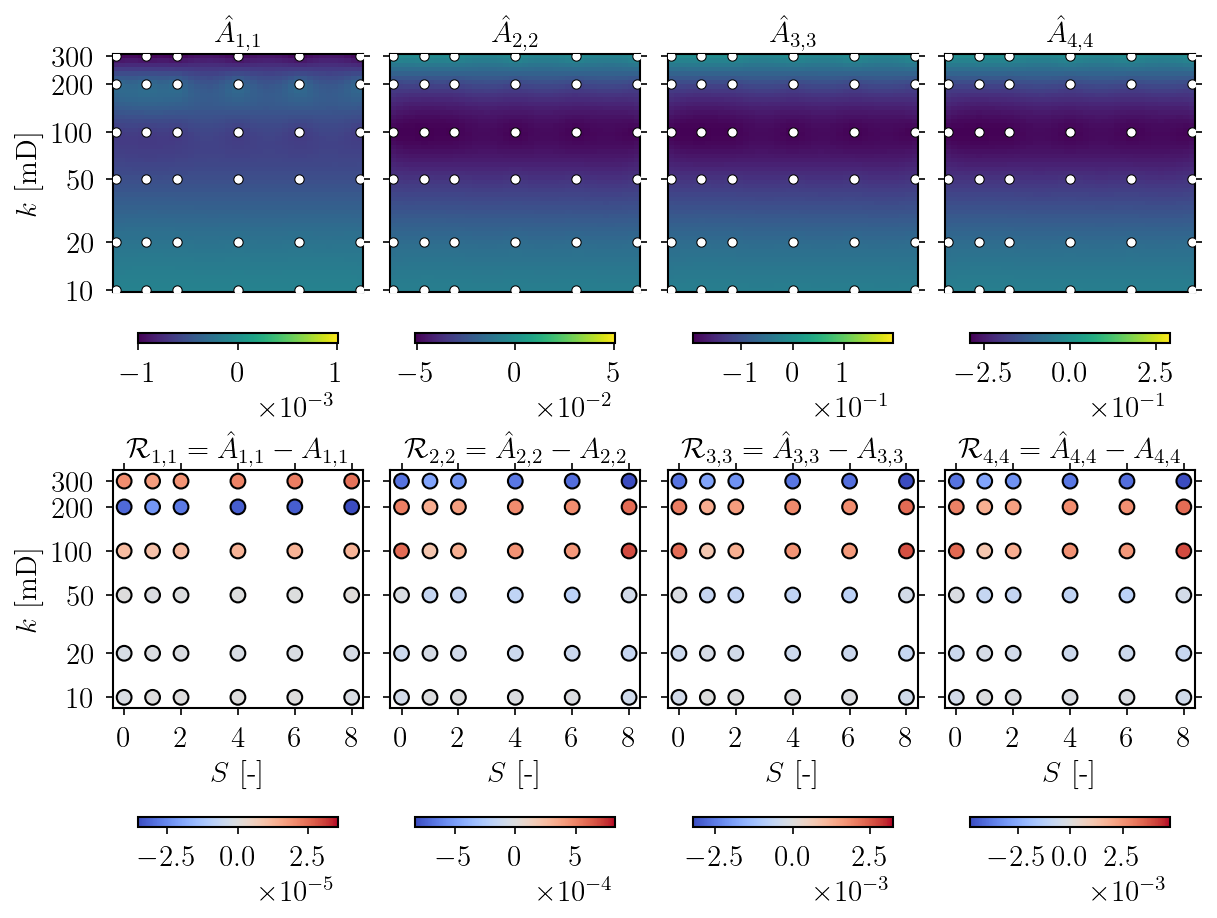

In [49]:

# --- Visualization: Surfaces and Corresponding Errors ---
k_fine = np.logspace(np.log10(10), np.log10(300), 55)
s_fine = np.linspace(0, 8, 40)
KK, SS = np.meshgrid(k_fine, s_fine)
n_diag = min(4, N_MODES)

# Calculate interpolated surfaces
diag = np.zeros((n_diag, *KK.shape))
for gi in range(KK.shape[0]):
    for gj in range(KK.shape[1]):
        A_q = eval_op(A_interps, A_shape, KK[gi,gj], SS[gi,gj])
        for m in range(n_diag):
            diag[m, gi, gj] = A_q[m, m]

# Calculate Residuals at Training Points
# We evaluate the model at the training points and subtract from the true values
residuals = []
for i, (k_val, s_val) in enumerate(zip([r['k'] for r in results if r['stable']], 
                                       [r['S'] for r in results if r['stable']])):
    A_pred = eval_op(A_interps, A_shape, k_val, s_val)
    A_true = A_arr[i]
    # Store error vector for the diagonal elements
    residuals.append([A_pred[m, m] - A_true[m, m] for m in range(n_diag)])
residuals = np.array(residuals)
# Setup Figure (2 rows, n_diag columns)
fig, axes = plt.subplots(2, n_diag, figsize=(8, 6), constrained_layout=True)

def log_tick_formatter(x, pos):
    """
    Formatter to display the original linear values on a log-scaled axis.
    Input x is log10(k), returns 10^x as a formatted string.
    """
    return f"{10**x:.0f}"
    
# Shared formatter for integer-style labels
class OffsetFormatter(ticker.ScalarFormatter):
    def __init__(self):
        super().__init__(useMathText=True)
        self.set_powerlimits((0, 0)) # Force scientific notation
        self.set_scientific(True)

for m in range(n_diag):
    # --- Top Row: Surface ---
    ax = axes[0, m]
    dat = diag[m]
    lim = np.abs(dat).max()
    im = ax.pcolormesh(SS, np.log10(KK), dat, cmap="viridis", shading="auto", vmin=-lim, vmax=lim)
    
    ax.scatter(valid_s, [np.log10(k) for k in valid_k], c="white", s=20, edgecolors="k", linewidths=0.5, zorder=5)
    ax.set_title(f"$\\hat{{A}}_{{{m+1},{m+1}}}$", fontsize=14)
    
    # --- Bottom Row: Error Residuals ---
    ax_err = axes[1, m]
    sc = ax_err.scatter(valid_s, [np.log10(k) for k in valid_k], c=residuals[:, m], 
                        cmap="coolwarm", s=50, edgecolors="k", 
                        vmin=-np.abs(residuals[:, m]).max(), vmax=np.abs(residuals[:, m]).max())
    ax_err.set_title(r"$\mathcal{R}_{" + f"{m+1},{m+1}" + r"} = \hat{A}_{" + f"{m+1},{m+1}" + r"} - A_{" + f"{m+1},{m+1}" + r"}$", fontsize=14)
    # Formatting
    for a in [ax, ax_err]:
        a.tick_params(axis='both', which='major', labelsize=14)
        a.set_yticks(np.log10(K_GRID))
        if m == 0:
            a.yaxis.set_major_formatter(ticker.FuncFormatter(log_tick_formatter))
            a.set_ylabel("$k$ [mD]", fontsize=14)
        else:
            a.set_yticklabels([])
    
    ax.set_xticks([])
    ax_err.set_xticks([0, 2, 4, 6, 8])
    ax_err.set_xlabel("$S$ [-]", fontsize=14)

    # --- Colorbars: Integer + Global Multiplier ---
    cb = fig.colorbar(im, ax=ax, orientation='horizontal', shrink=0.8, pad=0.1)
    cb.ax.tick_params(labelsize=14)
    # The ScalarFormatter automatically adds the 'x 10^n' label to the colorbar
    cb.formatter = OffsetFormatter()
    cb.update_ticks()
    #cb.set_label("Value", fontsize=14)
    
    cb_err = fig.colorbar(sc, ax=ax_err, orientation='horizontal', shrink=0.8, pad=0.1)
    cb_err.ax.tick_params(labelsize=14)
    cb_err.formatter = OffsetFormatter()
    cb_err.update_ticks()
    #cb_err.set_label("Residual", fontsize=14)
# Label for top colorbars (Value)
#fig.text(0.08, 0.60, 'Value', va='center', rotation='vertical', fontsize=14, fontweight='bold')

# Label for bottom colorbars (Residual)
#fig.text(0.04, 0.25, 'Residual', va='center', rotation='vertical', fontsize=14, fontweight='bold')
plt.show()

## 5. ROM Validation



In [31]:
def bourdet(t_hr, dp, L=0.2):
    """
    Calculates the Bourdet derivative for log-log diagnostic plots.
    """
    ln_t = np.log(t_hr); d = np.full_like(dp, np.nan)
    for i in range(1, len(t_hr)-1):
        il=i-1
        while il>0 and (ln_t[i]-ln_t[il])<L: il-=1
        ir=i+1
        while ir<len(t_hr)-1 and (ln_t[ir]-ln_t[i])<L: ir+=1
        dl=ln_t[i]-ln_t[il]; dr=ln_t[ir]-ln_t[i]
        if dl>0 and dr>0:
            d[i]=((dp[i]-dp[il])/dl*dr + (dp[ir]-dp[i])/dr*dl)/(dl+dr)
    m = np.isfinite(d) & (d>0) & (dp>0)
    return t_hr[m], dp[m], d[m]


def query_rom(k_star, s_star, t_hr, q_vec):
    """
    Evaluates the ROM for unseen (k, S) parameters using interpolated operators.
    """
    # 1. Evaluate ALL four interpolated operators for the query point
    A_hat = eval_op(A_interps, A_shape, k_star, s_star)
    B_hat = eval_op(B_interps, B_shape, k_star, s_star)
    C_hat = eval_op(C_interps, C_shape, k_star, s_star)
    D_hat = eval_op(D_interps, D_shape, k_star, s_star)


    

    # # 2. Enforce Numerical Stability
    # eigv, evecs = np.linalg.eig(A_hat)
    # unstable = eigv.real > 0
    # if np.any(unstable):
    #     # CRITICAL FIX: Clamp strictly to 0.0 to preserve the closed-tank integrator mode!
    #     eigv[unstable] = 0.0 + 1j * eigv[unstable].imag
    #     A_hat = np.real(evecs @ np.diag(eigv) @ np.linalg.inv(evecs))

    
    
    # 3. Time-Stepping via Backward Euler
    K  = len(t_hr)
    dt = np.diff(t_hr, prepend=0.0); dt[0] = t_hr[0]
    In = np.eye(N_MODES); xk = np.zeros(N_MODES)
    Xr = np.zeros((K, N_MODES))
    Yr = np.zeros(K)
    
    for j in range(K):
        # Update reduced state
        rhs   = xk + dt[j] * B_hat.ravel() * q_vec[j]
        xk    = np.linalg.solve(In - dt[j] * A_hat, rhs)
        Xr[j] = xk
        
        # Calculate Output (BHP Delta)
        # This implicitly includes the skin effect learned via the D matrix
        Yr[j] = float(C_hat @ xk + D_hat * q_vec[j])

    # 4. Final Reconstruction
    # Yr is the change in pressure from P_INIT
    bhp_psia = P_INIT + Yr
    
    # Optional: Reconstruct the full pressure field for the grid
    p_field  = P_INIT + (Vn @ Xr.T) 
    
    return bhp_psia, p_field, True


print("query_rom() with Direct Feedthrough defined.")

query_rom() with Direct Feedthrough defined.


### 5.2 Type-2 Validation — BHP and Bourdet Comparison

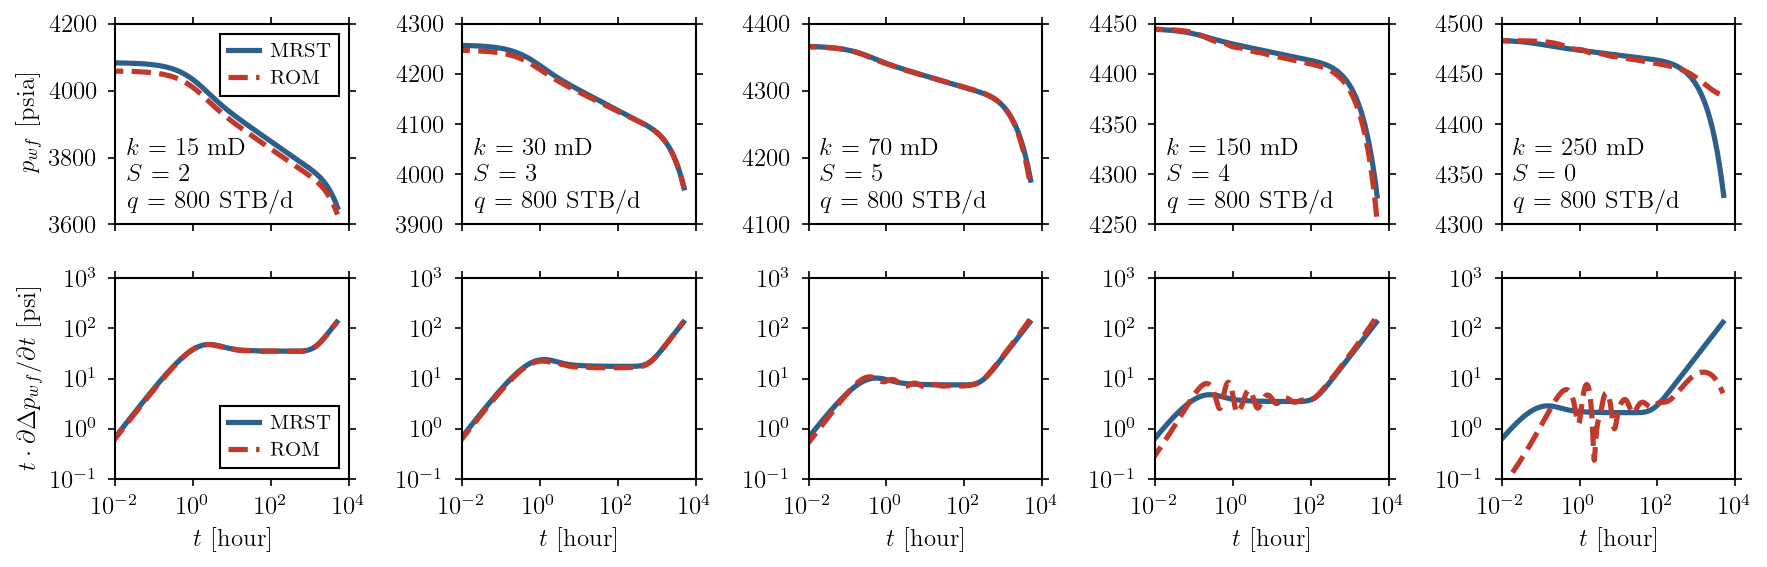

In [32]:
test_grid = [(15, 2, 1), (30, 3, 1), (70, 5, 1), (150, 4, 1), (250, 0, 1)]
val_base  = Path("F:/Niloy Deb/Part Two/reservoir_rom/data/02_validation")

custom_ylims_bhp = [(3600, 4200), (3900, 4300), (4100, 4400), (4250, 4450), (4300, 4500)]

fig, axes = plt.subplots(2, 5, figsize=(12, 4), sharex=True)

for i, (k_test, s_test, _) in enumerate(test_grid):
    # Panel indexing: Top row (0) for BHP, Bottom row (1) for Derivative
    ax_bhp = axes[0, i]
    ax_der = axes[1, i]
    
    k_str = str(int(k_test)).zfill(3)
    s_str = str(int(s_test)).zfill(2)
    folder_name = f"k{k_str}_s{s_str}_sched1"
    test_path = val_base / folder_name
    
    try:
        bhp_true, t_hr, q_v, _, _ = load_well_data(test_path)
        # Use query_rom with stable operator enforcement
        bhp_rom, _, _ = query_rom(k_test, s_test, t_hr, q_v)
        
        dp_true = P_INIT - bhp_true
        dp_rom  = P_INIT - bhp_rom
        t_t, p_t, d_t = bourdet(t_hr, dp_true, L=0.1) # Reduced L to see raw wiggles
        t_r, p_r, d_r = bourdet(t_hr, dp_rom,  L=0.1)
        
        # --- Top Row: BHP (Cartesian y, Log x) ---
        ax_bhp.semilogx(t_hr, bhp_true, lw=2.5, color=C_MRST, label='MRST')
        ax_bhp.semilogx(t_hr, bhp_rom,  lw=2.5, color=C_ROM, ls="--", label='ROM')
        
        # Parameter inset text
        info_text = (f"$k$ = {int(k_test)} mD\n"
                     f"$S$ = {int(s_test)}\n"
                     f"$q$ = 800 STB/d")
        ax_bhp.text(0.05, 0.05, info_text, 
                    transform=ax_bhp.transAxes, 
                    fontsize=12, 
                    verticalalignment="bottom")
        
        if i == 0: 
            ax_bhp.set_ylabel("$p_{wf}$ [psia]", fontsize=12)

        
        ax_bhp.set_xlim([0.01, 1e4])
        ax_bhp.set_ylim(custom_ylims_bhp[i])  # <-- Applied the custom y-limits array here
            
        ax_bhp.xaxis.set_minor_locator(NullLocator())
        ax_bhp.yaxis.set_minor_locator(NullLocator())
        ax_bhp.tick_params(labelsize=12)
        
        # --- Bottom Row: Bourdet Derivative (Log-Log) ---
        # MRST shown as scatter to clearly distinguish from the solid ROM curve on log-log
        ax_der.loglog(t_t, d_t, lw=2.5, color=C_MRST, label='MRST')
        ax_der.loglog(t_r, d_r, lw=2.5, color=C_ROM, ls="--", label='ROM')
        
        if i == 0: 
            ax_der.set_ylabel(r"$t \cdot \partial \Delta p_{wf} / \partial t$ [psi]", fontsize=12)
        
        ax_der.set_xlabel("$t$ [hour]", fontsize=12)
        ax_der.xaxis.set_minor_locator(NullLocator())
        ax_der.yaxis.set_minor_locator(NullLocator())
        ax_der.tick_params(labelsize=12)
        ax_der.set_xlim([0.01, 1e4])
        ax_der.set_ylim([0.1, 1000])
        
        # Add legend only to the first column to keep the plot clean
        if i == 0: 
            ax_bhp.legend(loc='upper right', fontsize=10)
            ax_der.legend(fontsize=10)

    except FileNotFoundError:
        ax_bhp.text(0.5, 0.5, "Data Missing", ha='center', va='center', transform=ax_bhp.transAxes, fontsize=12)

plt.tight_layout()
#sf("fig09_detailed_validation_five.pdf")
plt.show()

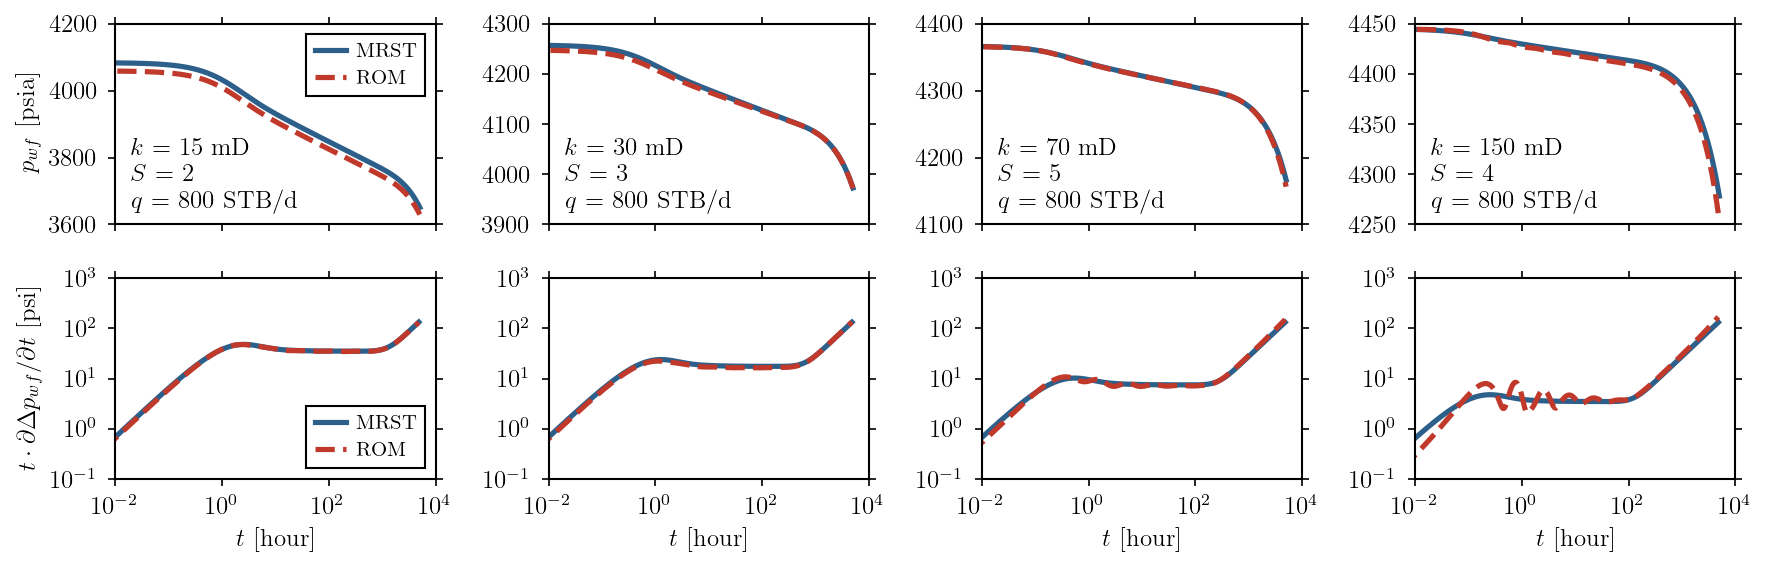

In [33]:
test_grid = [(15, 2, 1), (30, 3, 1), (70, 5, 1), (150, 4, 1)]
val_base  = Path("F:/Niloy Deb/Part Two/reservoir_rom/data/02_validation")

custom_ylims_bhp = [(3600, 4200), (3900, 4300), (4100, 4400), (4250, 4450), (4300, 4500)]

fig, axes = plt.subplots(2, 4, figsize=(12, 4), sharex=True)

for i, (k_test, s_test, _) in enumerate(test_grid):
    # Panel indexing: Top row (0) for BHP, Bottom row (1) for Derivative
    ax_bhp = axes[0, i]
    ax_der = axes[1, i]
    
    k_str = str(int(k_test)).zfill(3)
    s_str = str(int(s_test)).zfill(2)
    folder_name = f"k{k_str}_s{s_str}_sched1"
    test_path = val_base / folder_name
    
    try:
        bhp_true, t_hr, q_v, _, _ = load_well_data(test_path)
        # Use query_rom with stable operator enforcement
        bhp_rom, _, _ = query_rom(k_test, s_test, t_hr, q_v)
        
        dp_true = P_INIT - bhp_true
        dp_rom  = P_INIT - bhp_rom
        t_t, p_t, d_t = bourdet(t_hr, dp_true, L=0.1) # Reduced L to see raw wiggles
        t_r, p_r, d_r = bourdet(t_hr, dp_rom,  L=0.1)
        
        # --- Top Row: BHP (Cartesian y, Log x) ---
        ax_bhp.semilogx(t_hr, bhp_true, lw=2.5, color=C_MRST, label='MRST')
        ax_bhp.semilogx(t_hr, bhp_rom,  lw=2.5, color=C_ROM, ls="--", label='ROM')
        
        # Parameter inset text
        info_text = (f"$k$ = {int(k_test)} mD\n"
                     f"$S$ = {int(s_test)}\n"
                     f"$q$ = 800 STB/d")
        ax_bhp.text(0.05, 0.05, info_text, 
                    transform=ax_bhp.transAxes, 
                    fontsize=12, 
                    verticalalignment="bottom")
        
        if i == 0: 
            ax_bhp.set_ylabel("$p_{wf}$ [psia]", fontsize=12)

        
        ax_bhp.set_xlim([0.01, 1e4])
        ax_bhp.set_ylim(custom_ylims_bhp[i])  # <-- Applied the custom y-limits array here
            
        ax_bhp.xaxis.set_minor_locator(NullLocator())
        ax_bhp.yaxis.set_minor_locator(NullLocator())
        ax_bhp.tick_params(labelsize=12)
        
        # --- Bottom Row: Bourdet Derivative (Log-Log) ---
        # MRST shown as scatter to clearly distinguish from the solid ROM curve on log-log
        ax_der.loglog(t_t, d_t, lw=2.5, color=C_MRST, label='MRST')
        ax_der.loglog(t_r, d_r, lw=2.5, color=C_ROM, ls="--", label='ROM')
        
        if i == 0: 
            ax_der.set_ylabel(r"$t \cdot \partial \Delta p_{wf} / \partial t$ [psi]", fontsize=12)
        
        ax_der.set_xlabel("$t$ [hour]", fontsize=12)
        ax_der.xaxis.set_minor_locator(NullLocator())
        ax_der.yaxis.set_minor_locator(NullLocator())
        ax_der.tick_params(labelsize=12)
        ax_der.set_xlim([0.01, 1e4])
        ax_der.set_ylim([0.1, 1000])
        
        # Add legend only to the first column to keep the plot clean
        if i == 0: 
            ax_bhp.legend(fontsize=10)
            ax_der.legend(fontsize=10)

    except FileNotFoundError:
        ax_bhp.text(0.5, 0.5, "Data Missing", ha='center', va='center', transform=ax_bhp.transAxes, fontsize=12)

plt.tight_layout()
#sf("fig09_detailed_validation_four.pdf")
plt.show()

### 5.3 Pressure Field Accuracy

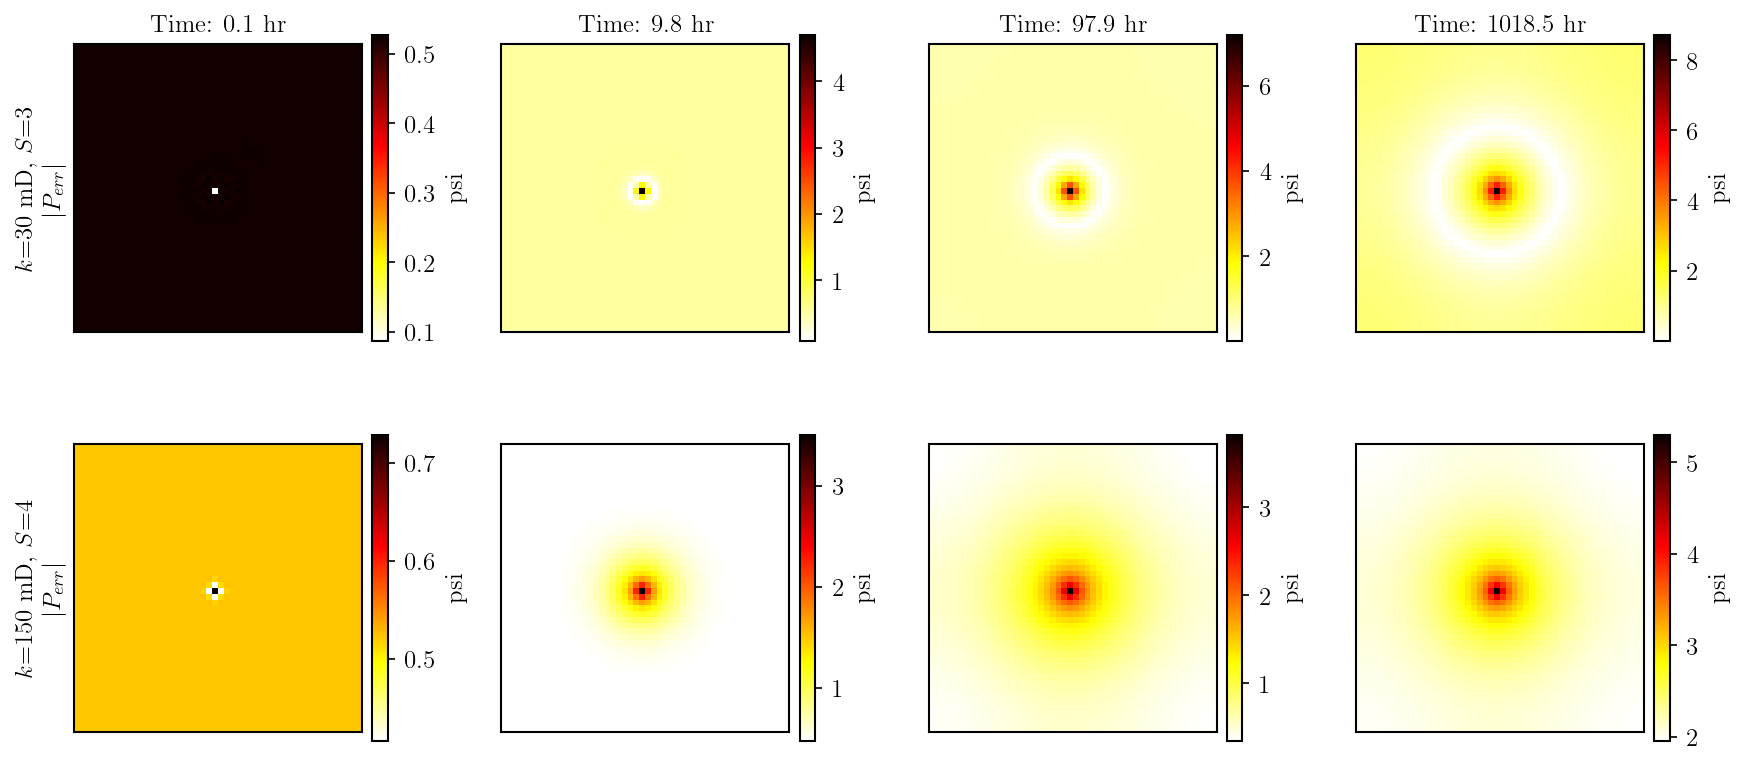

In [34]:
spatial_test_cases = [(30, 3, 1), (150, 4, 1)] 
times_to_plot = [0.1, 10, 100, 1000] # Target times in hours

NR = len(spatial_test_cases)
NC = len(times_to_plot)

fig, axes = plt.subplots(NR, NC, figsize=(12, 6))

for row, (k_v, s_v, sid) in enumerate(spatial_test_cases):
    # Construct folder name
    k_str, s_str = str(k_v).zfill(3), str(s_v).zfill(2)
    folder_name = f"k{k_str}_s{s_str}_sched{sid}"
    cd = val_base / folder_name
    
    # Load Truth (MRST Snapshots)
    # Using load_mat as defined in your previous cells
    X_m = load_mat(cd/"snapshots_psia.mat", "X_psia") 
    bhp_m, t_hr, q_v, _, pm = load_well_data(cd)
    
    # Query ROM (Calculates full field pf_r = P_INIT + Vn @ Xr.T)
    _, pf_r, _ = query_rom(k_v, s_v, t_hr, q_v)
    
    for col, t_target in enumerate(times_to_plot):
        # Find the closest simulation time index
        idx = int(np.argmin(np.abs(t_hr - t_target)))
        
        # Calculate Delta P Maps
        dp_m = (X_m[:, idx] - P_INIT).reshape(NY, NX)
        dp_r = (pf_r[:, idx] - P_INIT).reshape(NY, NX)
        
        # Calculate Absolute Error Map
        err_map = np.abs(dp_m - dp_r)
        
        # State Error Metric (Frobenius norm over all space/time)
        se = (np.linalg.norm(X_m[:, idx] - pf_r[:, idx]) / 
              np.linalg.norm(X_m[:, idx] - P_INIT))
        
        ax = axes[row, col]
        im = ax.imshow(err_map, origin="lower", cmap="hot_r", aspect="equal")
        
        # Add well location marker (Center) - Commented out for minimal clean style
        # ax.plot(NX//2, NY//2, "w+", ms=8, mew=1.5)
        
        # Formatting
        ax.set_xticks([])
        ax.set_yticks([])
        
        if row == 0: 
            ax.set_title(f"Time: {t_hr[idx]:.1f} hr", fontweight='normal', fontsize=12)
        if col == 0: 
            ax.set_ylabel(f"$k$={k_v} mD, $S$={s_v}\n$|P_{{err}}|$", fontweight='normal', fontsize=12)
        
        # Annotate with the specific error for that snapshot
        # New code using fixed-point decimal notation (.3f)
        # ax.text(0.05, 0.05, f"$\epsilon={se * 100:.1f}\%$", transform=ax.transAxes, 
        #         color="black", fontsize=12, bbox=dict(facecolor='white', alpha=0.7))
        
        # Clean colorbar formatting
        cb = plt.colorbar(im, ax=ax, shrink=0.7, pad=0.03)
        cb.set_label('psi', size=12)
        cb.ax.tick_params(labelsize=12)

# plt.suptitle("Spatial Error Evolution: Blind Validation Snapshots", fontsize=14, y=0.98)
plt.tight_layout(h_pad=1.0)
#sf("fig10_spatial_validation.pdf")
plt.show()

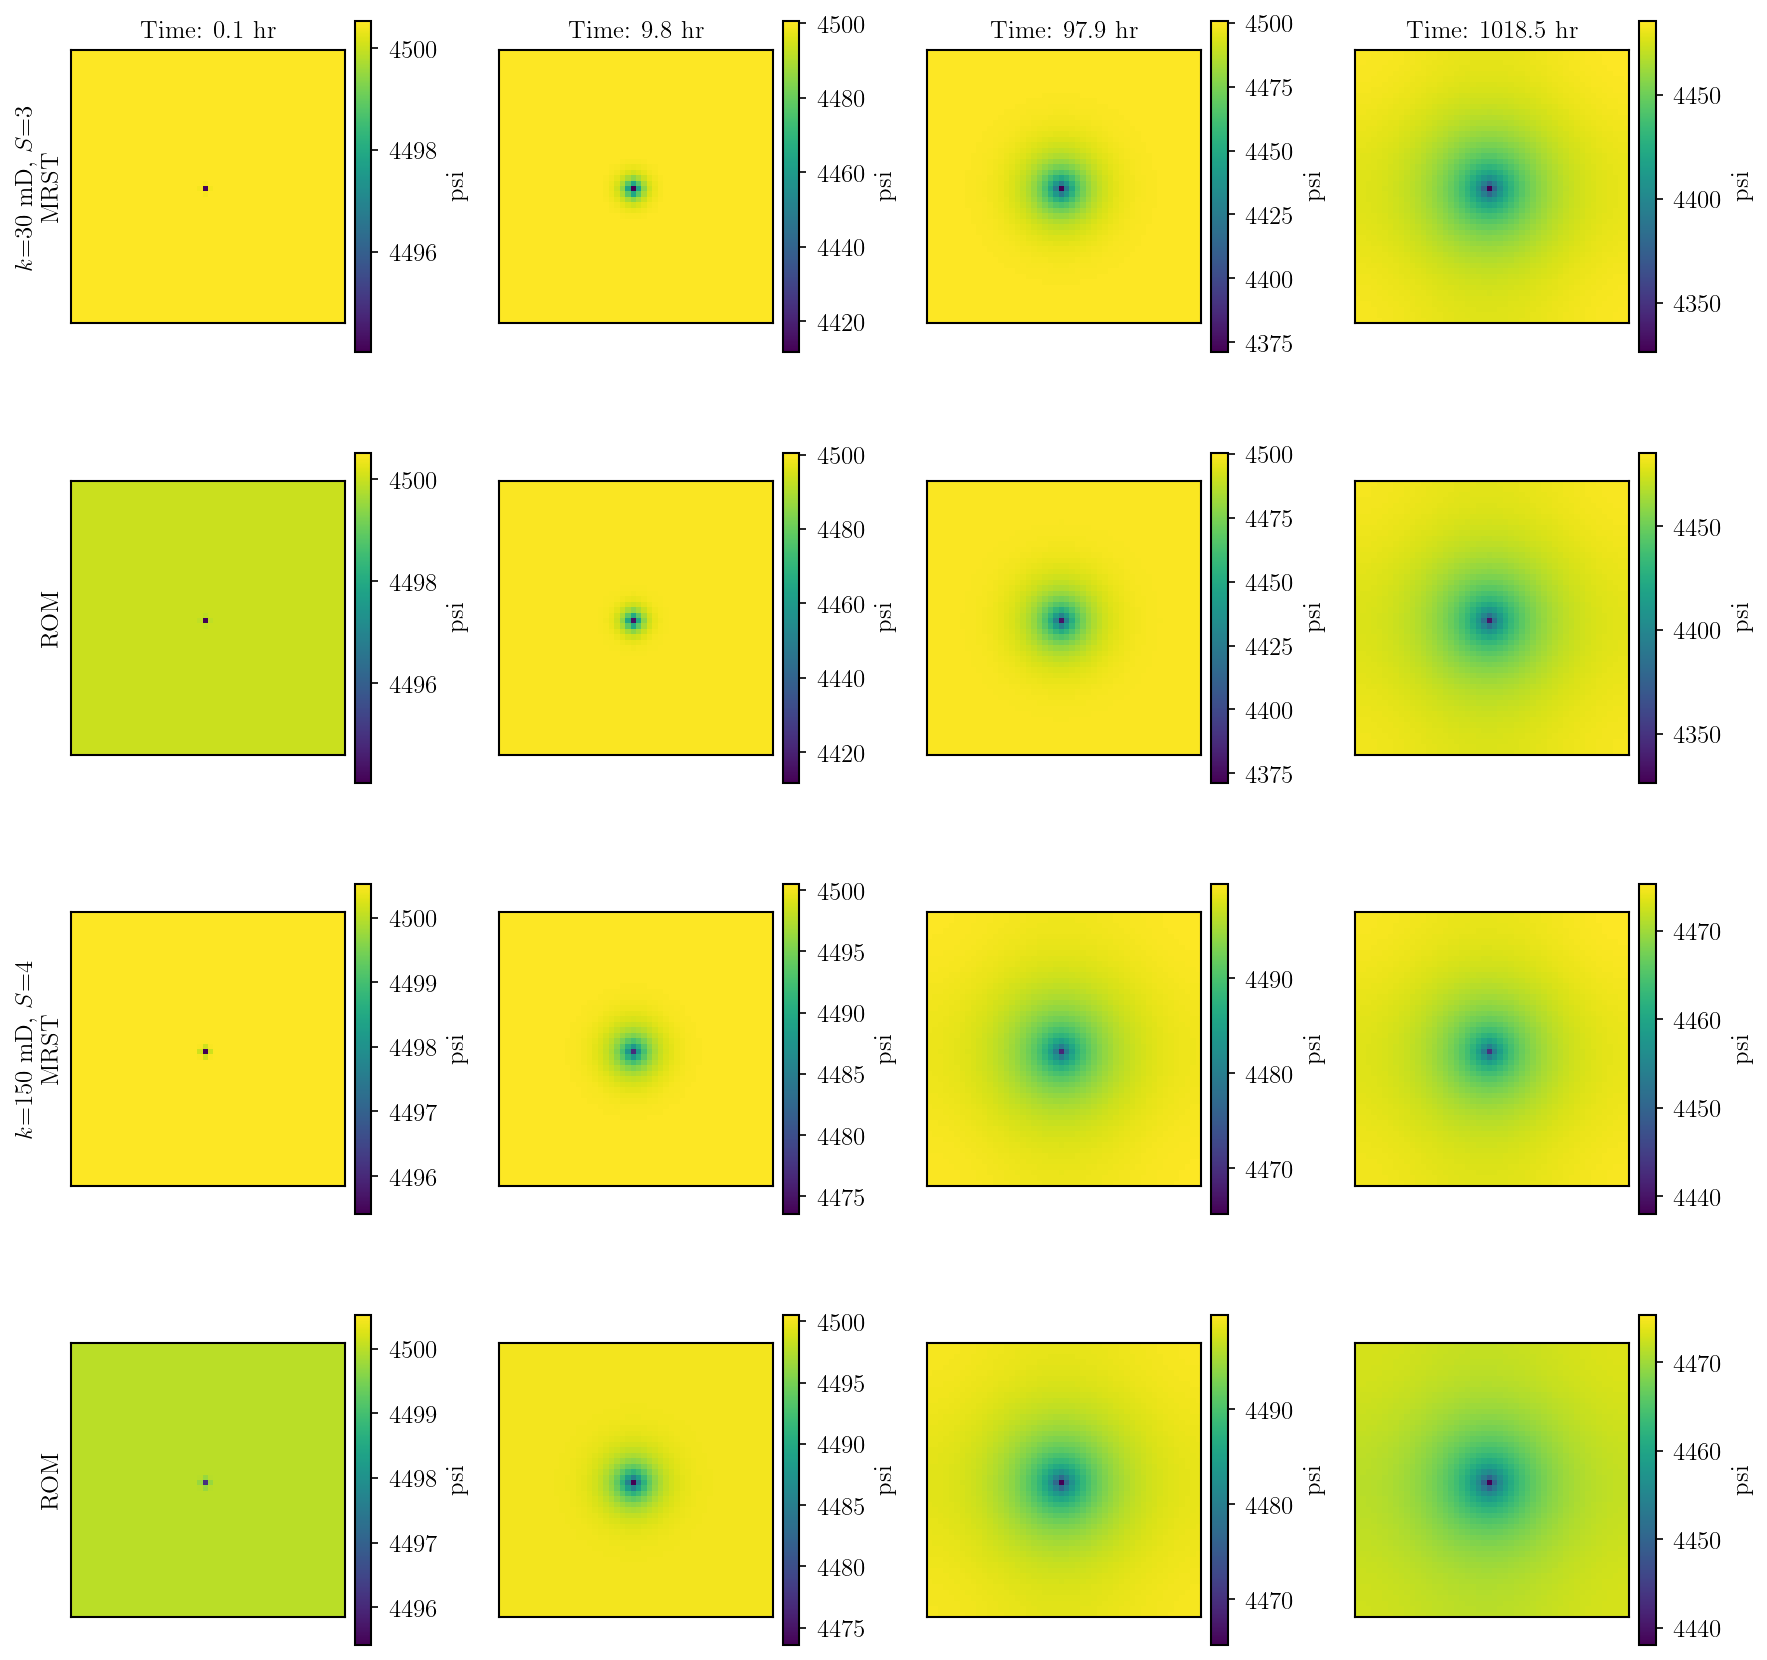

In [35]:
# 2. Spatial Comparison: Actual Pressure Fields (MRST vs ROM)
spatial_test_cases = [(30, 3, 1), (150, 4, 1)] 
times_to_plot = [0.1, 10, 100, 1000] # Target times in hours

# We need 2 rows per case (one for MRST, one for ROM)
NC = len(times_to_plot)
NR = len(spatial_test_cases) * 2 

fig, axes = plt.subplots(NR, NC, figsize=(12,12))

for i, (k_v, s_v, sid) in enumerate(spatial_test_cases):
    # Construct folder name
    k_str, s_str = str(k_v).zfill(3), str(s_v).zfill(2)
    folder_name = f"k{k_str}_s{s_str}_sched{sid}"
    cd = val_base / folder_name
    
    # Load Truth (MRST Snapshots)
    X_m = load_mat(cd/"snapshots_psia.mat", "X_psia") 
    bhp_m, t_hr, q_v, _, pm = load_well_data(cd)
    
    # Query ROM
    _, pf_r, _ = query_rom(k_v, s_v, t_hr, q_v)
    
    # Define row indices for this specific case
    row_mrst = i * 2
    row_rom = (i * 2) + 1
    
    for col, t_target in enumerate(times_to_plot):
        # Find the closest simulation time index
        idx = int(np.argmin(np.abs(t_hr - t_target)))
        
        # Extract full pressure fields (No P_INIT subtraction this time)
        p_mrst = X_m[:, idx].reshape(NY, NX)
        p_rom = pf_r[:, idx].reshape(NY, NX)
        
        # CRITICAL: Lock the color scale bounds so both plots use the exact same colors
        vmin = min(p_mrst.min(), p_rom.min())
        vmax = max(p_mrst.max(), p_rom.max())
        
        # --- Plot MRST (Top Row) ---
        ax_m = axes[row_mrst, col]
        im_m = ax_m.imshow(p_mrst, origin="lower", cmap="viridis", vmin=vmin, vmax=vmax, aspect="equal")
        # ax_m.plot(NX//2, NY//2, "w+", ms=8, mew=1.5) # Commented out for minimal clean style
        ax_m.set_xticks([]); ax_m.set_yticks([])
        
        # --- Plot ROM (Bottom Row) ---
        ax_r = axes[row_rom, col]
        im_r = ax_r.imshow(p_rom, origin="lower", cmap="viridis", vmin=vmin, vmax=vmax, aspect="equal")
        # ax_r.plot(NX//2, NY//2, "w+", ms=8, mew=1.5) # Commented out for minimal clean style
        ax_r.set_xticks([]); ax_r.set_yticks([])
        
        # --- Formatting and Labels ---
        if row_mrst == 0: 
            ax_m.set_title(f"Time: {t_hr[idx]:.1f} hr", fontsize=12, fontweight='normal')
            
        if col == 0: 
            ax_m.set_ylabel(f"$k$={k_v} mD, $S$={s_v}\nMRST", fontsize=12, fontweight='normal')
            ax_r.set_ylabel(f"ROM", fontsize=12, fontweight='normal')
            
        # Add colorbars for both to verify limits match
        cb_m = plt.colorbar(im_m, ax=ax_m, shrink=0.75, pad=0.03)
        cb_m.set_label('psi', size=12)
        cb_m.ax.tick_params(labelsize=12)
        
        cb_r = plt.colorbar(im_r, ax=ax_r, shrink=0.75, pad=0.03)
        cb_r.set_label('psi', size=12)
        cb_r.ax.tick_params(labelsize=12)

# plt.suptitle("Spatial Pressure Field Evolution: MRST vs. ROM", fontsize=16, y=0.99, fontweight='bold')
plt.tight_layout(h_pad=1.5)
#sf("fig11_spatial_comparison.pdf")
plt.show()

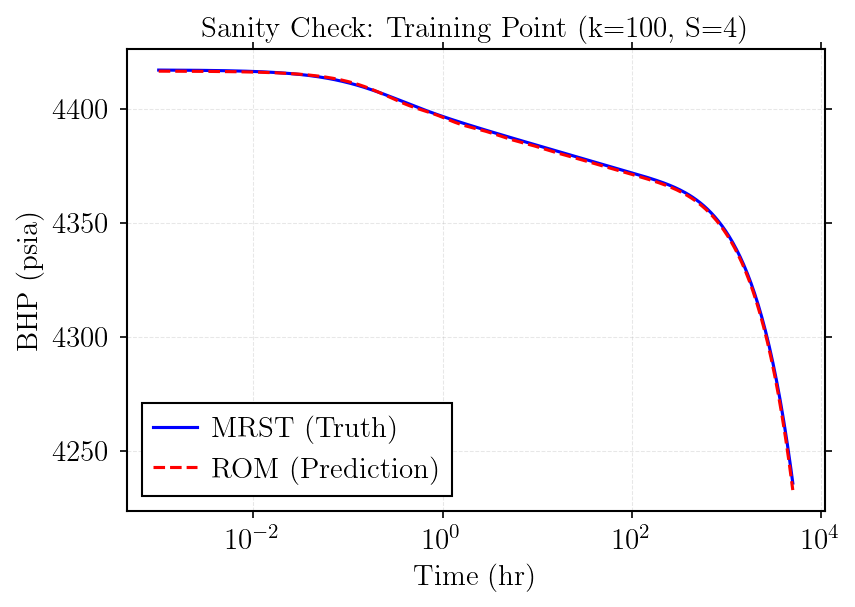

In [36]:
# Path to a training case it has already seen
train_path = TRAINING_DIR / "k100_s04_sched1" 

# Load the true MRST data
bhp_true, t_hr, q_v, _, _ = load_well_data(train_path)

# Query the ROM for the same parameters
bhp_rom, _, _ = query_rom(100, 4, t_hr, q_v)

# Plot
plt.figure(figsize=(6, 4))
plt.plot(t_hr, bhp_true, 'b-', label='MRST (Truth)')
plt.plot(t_hr, bhp_rom, 'r--', label='ROM (Prediction)')
plt.xscale('log')
plt.title("Sanity Check: Training Point (k=100, S=4)")
plt.ylabel("BHP (psia)")
plt.xlabel("Time (hr)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. ROM Prediction and Parametric Studies



In [22]:
T_PRED = np.logspace(np.log10(T_START), np.log10(T_END), N_STEPS)

def schedule_qvec(sched, t_hr):
    q = np.full(len(t_hr), float(sched[0][1]))
    for tc, rv in sched[1:]:
        q[t_hr >= tc] = float(rv)
    return q

def predict(k_star, s_star, rate_sched):
    assert 10 <= k_star <= 300, f"k={k_star} outside [10,300] mD"
    assert  0 <= s_star <=  8,  f"S={s_star} outside [0,8]"
    q   = schedule_qvec(rate_sched, T_PRED)
    t0  = time.perf_counter()
    bhp, pf, stable = query_rom(k_star, s_star, T_PRED, q)
    return dict(t_hr=T_PRED, bhp_psia=bhp,
                dp_psi=np.clip(P_INIT-bhp, 0, None),
                p_field=pf, q_vec=q, stable=stable,
                wall_ms=(time.perf_counter()-t0)*1000)

print("predict() ready.  Valid range: k in [10, 300] mD,  S in {0, 8}")

predict() ready.  Valid range: k in [10, 300] mD,  S in {0, 8}


### 6.1 Study A — Multi-rate Schedule ($k=75$ mD, $S=1$)

k=75, S=1 | Wall: 8.4 ms | Stable: True
BHP: 4337.7 - 4432.9 psia
t_WBS = 0.06 hr


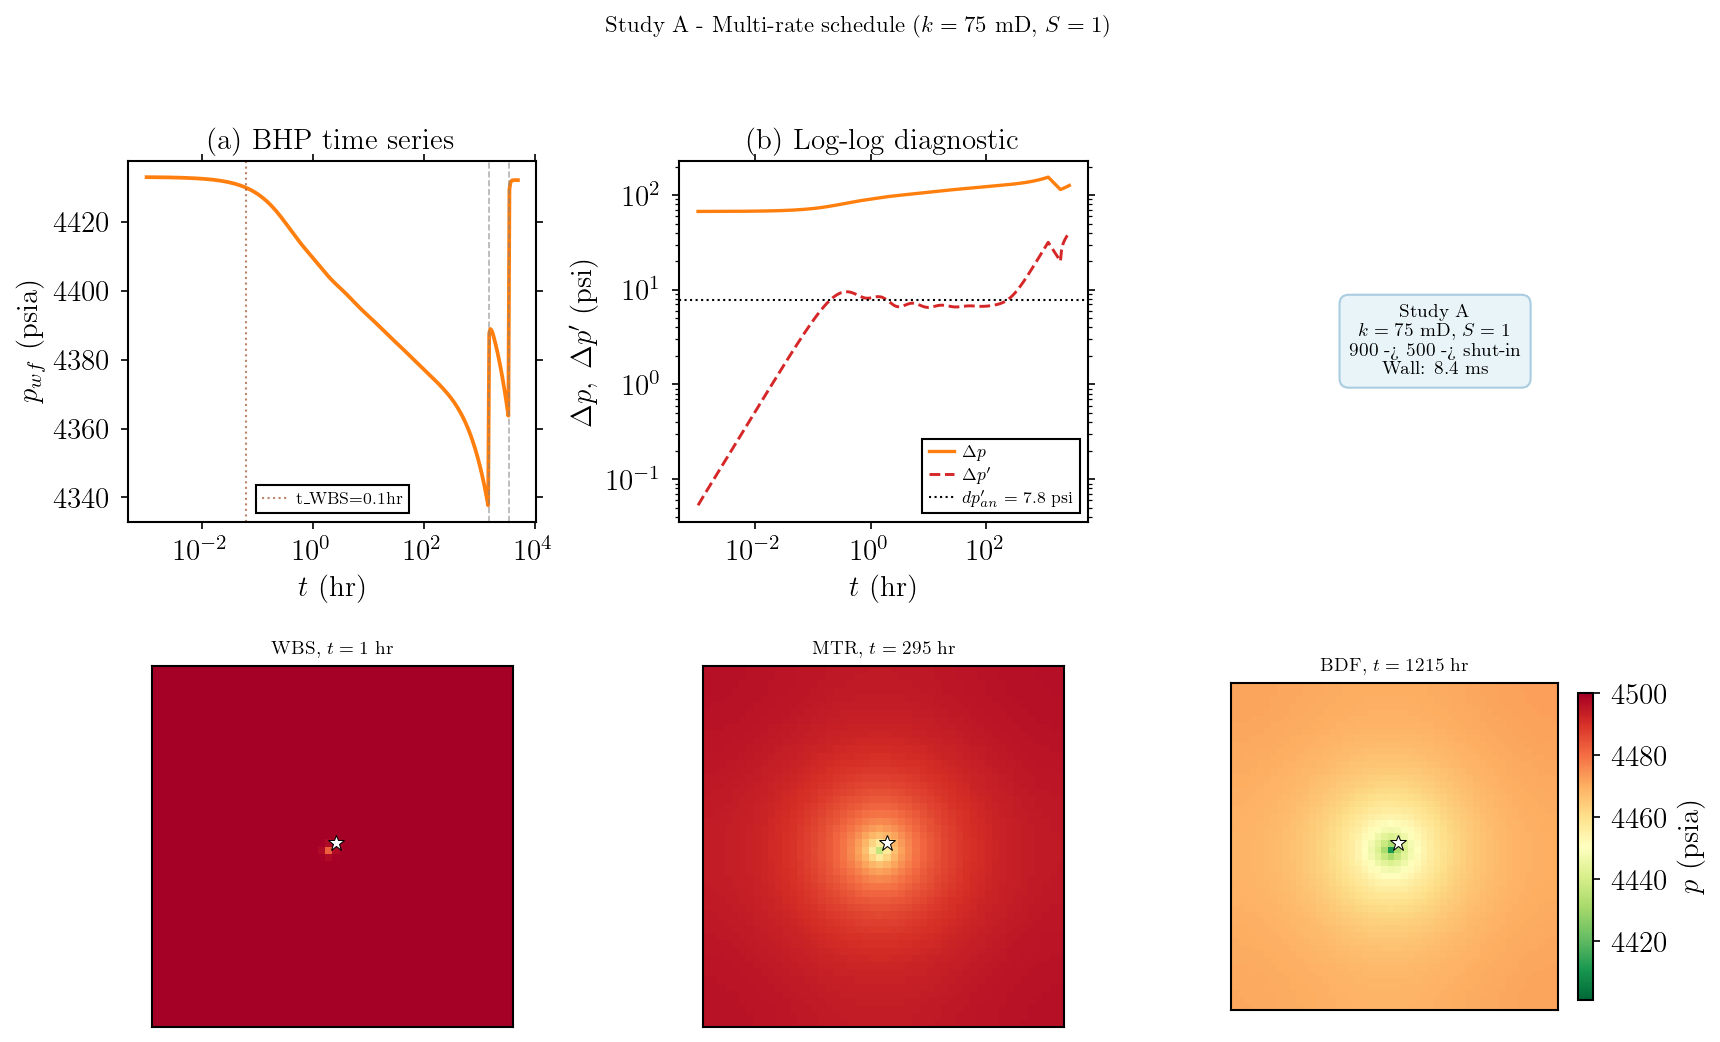

Figure saved.


In [23]:
k_val, s_val = 75, 1
rA = predict(k_val, s_val, [(0, 900), (1500, 500), (3500, 0)])

# Fixed: explicitly pass k_val and s_val
t_wbs_A = 170000.0 * C_WBS * np.exp(0.14 * s_val) * MU_CP / (k_val * H_FT)

print(f"k={k_val}, S={s_val} | Wall: {rA['wall_ms']:.1f} ms | Stable: {rA['stable']}")
print(f"BHP: {rA['bhp_psia'].min():.1f} - {rA['bhp_psia'].max():.1f} psia")
print(f"t_WBS = {t_wbs_A:.2f} hr")

dpA  = np.clip(rA["dp_psi"], 1e-2, None)
tA, dpA_b, bdA = bourdet(rA["t_hr"], dpA)
dp_an_A = 70.6 * 900 * MU_CP * BO / (k_val * H_FT)

fig = plt.figure(figsize=(13, 7.5))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.40, wspace=0.35)

ax1 = fig.add_subplot(gs[0,0])
ax1.semilogx(rA["t_hr"], rA["bhp_psia"], color="C1", lw=1.8)
for tc, _ in [(1500,None),(3500,None)]:
    ax1.axvline(tc, color="gray", ls="--", lw=0.8, alpha=0.6)
ax1.axvline(t_wbs_A, color="sienna", ls=":", lw=1.0, alpha=0.7, label=f"t_WBS={t_wbs_A:.1f}hr")
ax1.set_xlabel("$t$ (hr)"); ax1.set_ylabel("$p_{wf}$ (psia)")
ax1.set_title("(a)  BHP time series"); ax1.legend(fontsize=8)

ax2 = fig.add_subplot(gs[0,1])
if len(bdA)>2:
    ax2.loglog(tA, dpA_b, color="C1", lw=1.6, label=r"$\Delta p$")
    ax2.loglog(tA, bdA,   color="C3", lw=1.4, ls="--", label=r"$\Delta p'$")
ax2.axhline(dp_an_A, color="k", ls=":", lw=1, label=f"$dp'_{{an}}={dp_an_A:.1f}$ psi")
ax2.set_xlabel("$t$ (hr)"); ax2.set_ylabel(r"$\Delta p,\;\Delta p'$ (psi)")
ax2.set_title("(b)  Log-log diagnostic"); ax2.legend(fontsize=8)

snaps = [("WBS",np.argmin(np.abs(rA["t_hr"]-0.5))),
         ("MTR",np.argmin(np.abs(rA["t_hr"]-300))),
         ("BDF",np.argmin(np.abs(rA["t_hr"]-1200)))]
pm_pf = rA["p_field"].min(); px_pf = rA["p_field"].max()

for col,(lbl,idx) in enumerate(snaps):
    ax = fig.add_subplot(gs[1,col])
    im  = ax.imshow(rA["p_field"][:,idx].reshape(NY,NX),
                    origin="lower",cmap="RdYlGn_r",vmin=pm_pf,vmax=px_pf,aspect="equal")
    ax.plot(NX//2,NY//2,"w*",ms=8,mec="k",mew=0.5,zorder=5)
    ax.set_title(f"{lbl},  $t={rA['t_hr'][idx]:.0f}$ hr", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    if col==2: plt.colorbar(im,ax=ax,shrink=0.85,label="$p$ (psia)")

ax_i = fig.add_subplot(gs[0,2]); ax_i.axis("off")
ax_i.text(0.5,0.5,
    f"Study A\n$k={k_val}$ mD,  $S={s_val}$\n900 -> 500 -> shut-in\nWall: {rA['wall_ms']:.1f} ms",
    ha="center",va="center",fontsize=9,
    bbox=dict(boxstyle="round,pad=0.5",fc="#e8f4f8",ec="#aacce0"))
fig.suptitle(f"Study A - Multi-rate schedule  ($k={k_val}$ mD, $S={s_val}$)",
             fontsize=11,fontweight="bold",y=1.01)
plt.savefig(FIG_DIR/"fig10_studyA.png",dpi=150,bbox_inches="tight")
plt.show(); print("Figure saved.")

### 6.2 Study B — Permeability Sweep ($S=1$, $q=800$ STB/d)

Total wall time: 58 ms


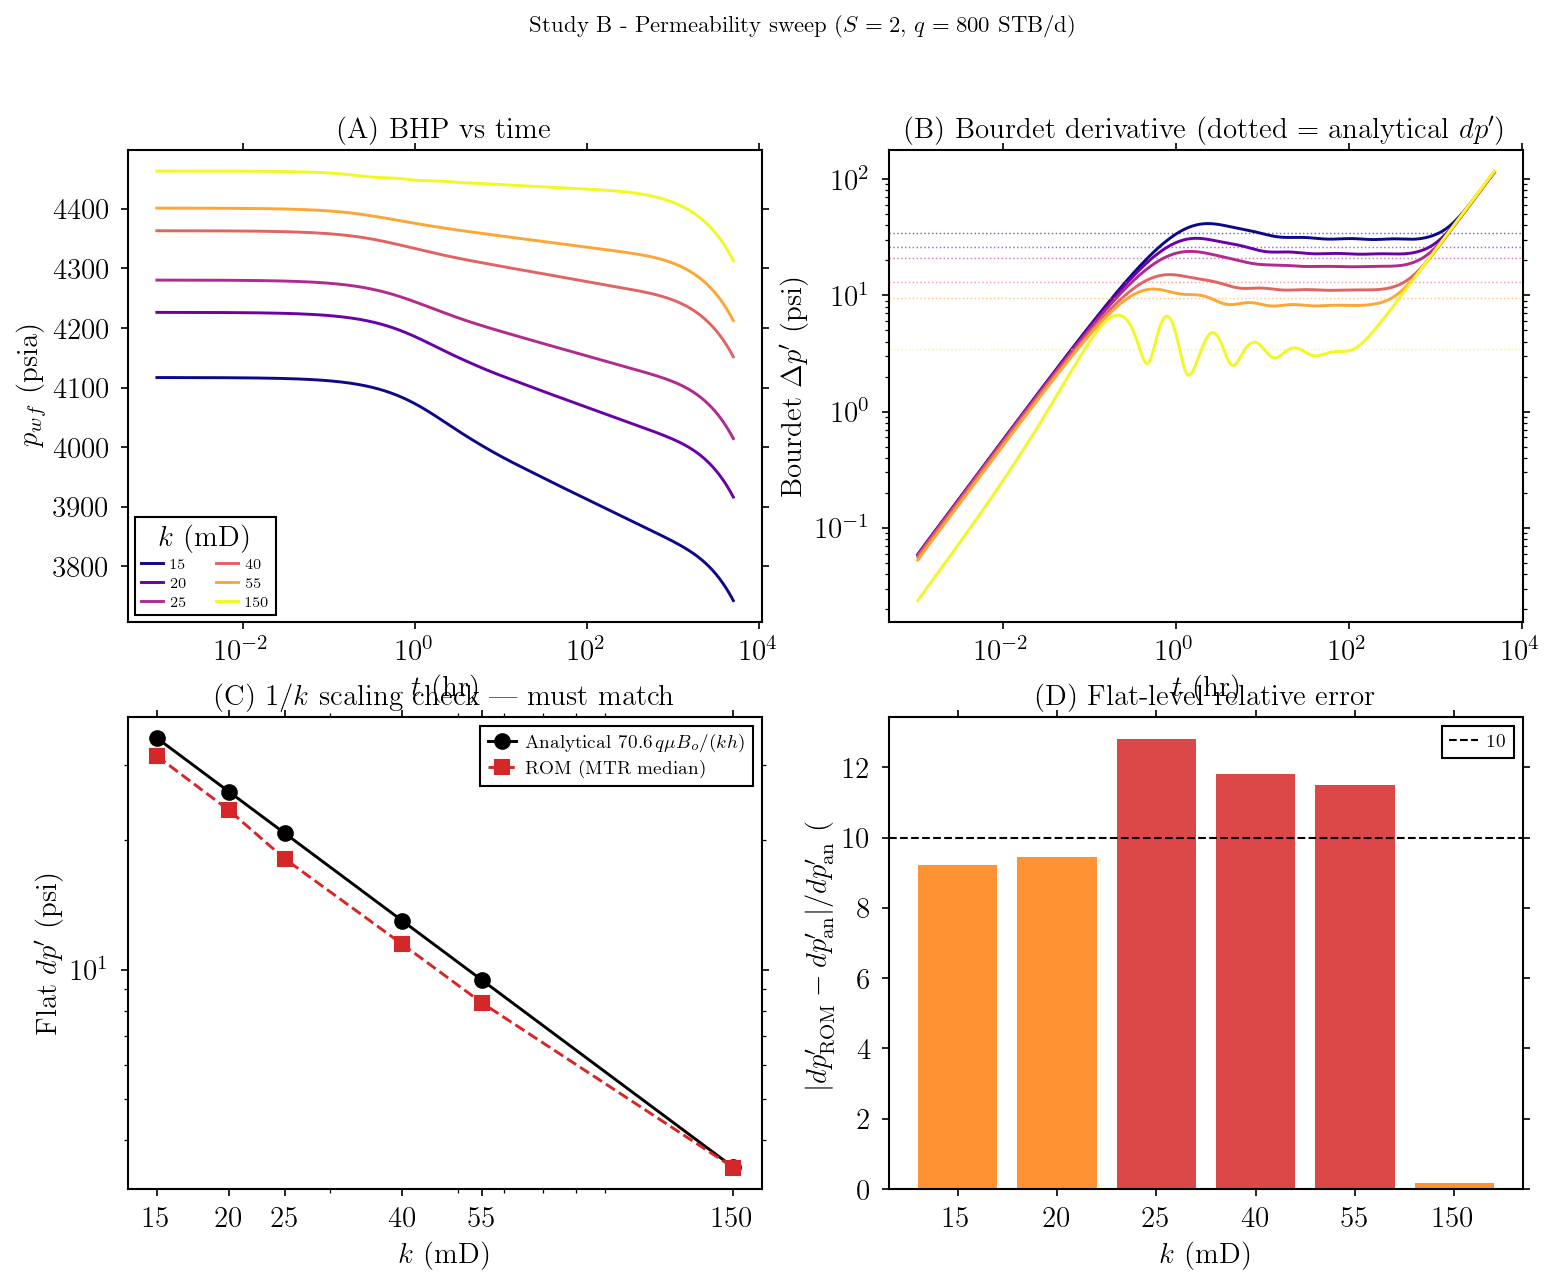

Figure saved.


In [24]:
k_sweep = [15, 20, 25, 40,  55, 150]
S_fixed = 2
cmap_b  = plt.cm.plasma
cols_b  = [cmap_b(i/(len(k_sweep)-1)) for i in range(len(k_sweep))]
res_B   = {k: predict(k, S_fixed, [(0,800)]) for k in k_sweep}
print(f"Total wall time: {sum(r['wall_ms'] for r in res_B.values()):.0f} ms")

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for k_v, col in zip(k_sweep, cols_b):
    r = res_B[k_v]
    axes[0,0].semilogx(r["t_hr"], r["bhp_psia"], color=col, lw=1.4, label=f"{k_v}")
axes[0,0].set_xlabel("$t$ (hr)"); axes[0,0].set_ylabel("$p_{wf}$ (psia)")
axes[0,0].set_title("(A)  BHP vs time")
axes[0,0].legend(title="$k$ (mD)", fontsize=7, ncol=2)

flat_sim = []; flat_an = []
for k_v, col in zip(k_sweep, cols_b):
    r   = res_B[k_v]
    dp  = np.clip(r["dp_psi"], 0.1, None)
    t_,d_,bd = bourdet(r["t_hr"], dp)
    if len(bd)>3: axes[0,1].loglog(t_, bd, color=col, lw=1.4)
    dp_an = 70.6 * 800 * MU_CP * BO / (k_v * H_FT)
    axes[0,1].axhline(dp_an, color=col, ls=":", lw=0.7, alpha=0.6)
    
    t_pss = (PHI*MU_CP*CT*RE_FT**2) / (0.000264*k_v) * 0.1
    # Fixed: passed S_fixed and k_v
    t_wbs_k = 170000.0 * C_WBS * np.exp(0.14 * S_fixed) * MU_CP / (k_v * H_FT) 
    
    mtr_m = (t_ >= t_wbs_k) & (t_ <= t_pss)
    flat_sim.append(float(np.median(bd[mtr_m])) if mtr_m.sum()>3 else np.nan)
    flat_an.append(dp_an)

axes[0,1].set_xlabel("$t$ (hr)"); axes[0,1].set_ylabel(r"Bourdet $\Delta p'$ (psi)")
axes[0,1].set_title(r"(B)  Bourdet derivative  (dotted = analytical $dp'$)")

axes[1,0].loglog(k_sweep, flat_an, "k-o", lw=1.4, ms=7,
                 label=r"Analytical $70.6\,q\mu B_o/(kh)$")
axes[1,0].loglog(k_sweep, flat_sim, "s--", color="C3", lw=1.4, ms=7,
                 label="ROM (MTR median)")
axes[1,0].set_xlabel("$k$ (mD)"); axes[1,0].set_ylabel(r"Flat $dp'$ (psi)")
axes[1,0].set_title(r"(C)  $1/k$ scaling check — must match")
axes[1,0].legend(fontsize=9)
axes[1,0].set_xticks(k_sweep); axes[1,0].set_xticklabels(k_sweep)

rel_err = [abs(s-a)/a*100 if not np.isnan(s) else np.nan
           for s,a in zip(flat_sim,flat_an)]
axes[1,1].bar(range(len(k_sweep)), rel_err,
              color=["C1" if e<10 else "C3" for e in rel_err], alpha=0.85)
axes[1,1].axhline(10, color="k", ls="--", lw=1, label="10% threshold")
axes[1,1].set_xticks(range(len(k_sweep))); axes[1,1].set_xticklabels(k_sweep)
axes[1,1].set_xlabel("$k$ (mD)"); axes[1,1].set_ylabel(r"$|dp'_\mathrm{ROM} - dp'_\mathrm{an}| / dp'_\mathrm{an}$ (%)")
axes[1,1].set_title("(D)  Flat-level relative error"); axes[1,1].legend(fontsize=9)

fig.suptitle(f"Study B - Permeability sweep  ($S={S_fixed}$, $q=800$ STB/d)",
             fontsize=11, fontweight="bold")
plt.savefig(FIG_DIR/"fig11_studyB.png", dpi=150, bbox_inches="tight")
plt.show(); print("Figure saved.")

### 6.3 Study C — Skin Sweep ($k=50$ mD, $q=800$ STB/d)

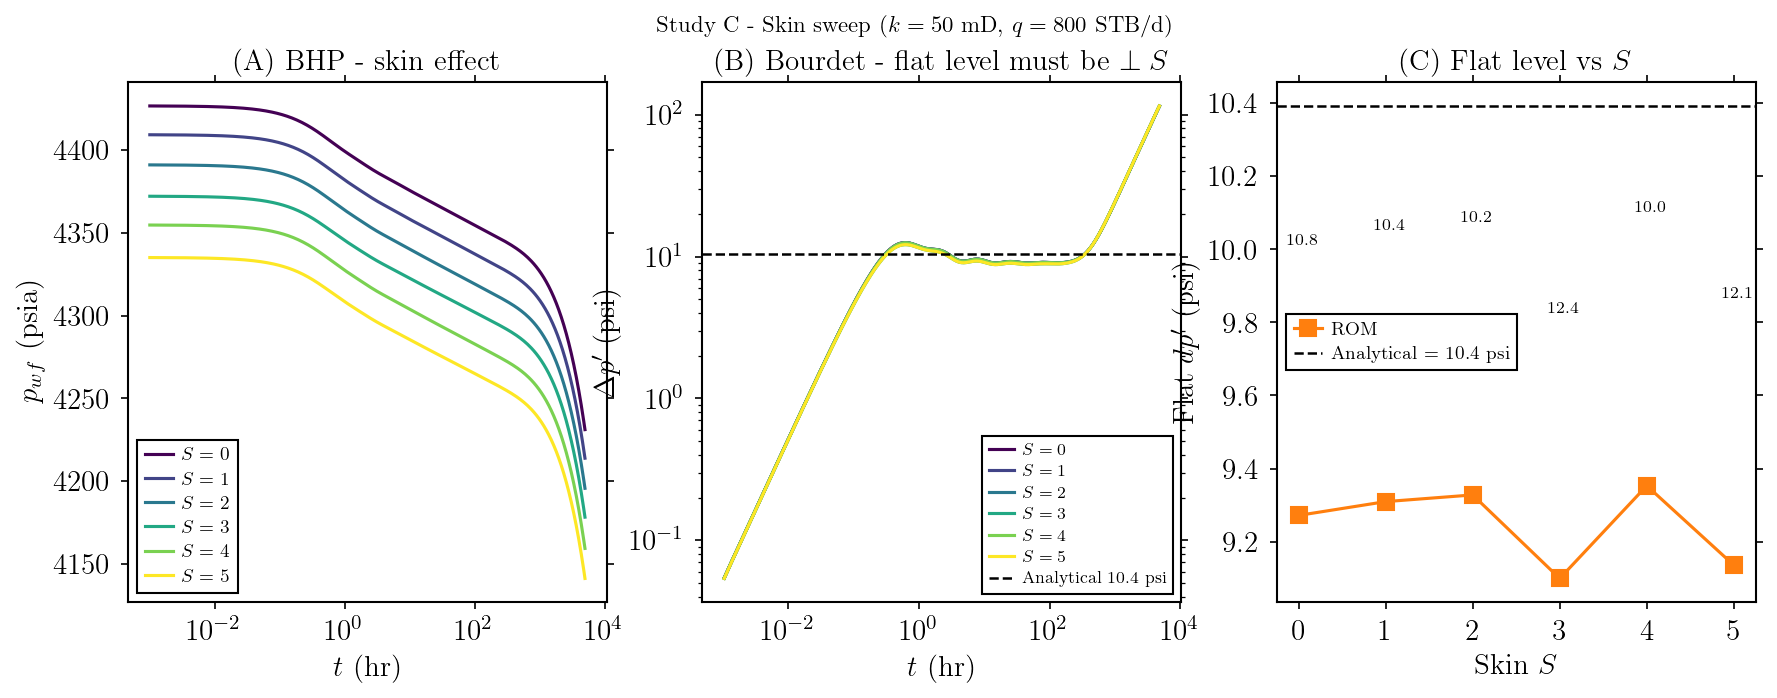

Figure saved.


In [25]:
S_sweep = [0, 1, 2, 3, 4, 5]
k_fixed = 50
cmap_c  = plt.cm.viridis
cols_c  = [cmap_c(i/(len(S_sweep)-1)) for i in range(len(S_sweep))]
res_C   = {s: predict(k_fixed, s, [(0,800)]) for s in S_sweep}
dp_an_k50 = 70.6 * 800 * MU_CP * BO / (k_fixed * H_FT)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for s_v, col in zip(S_sweep, cols_c):
    r = res_C[s_v]
    axes[0].semilogx(r["t_hr"], r["bhp_psia"], color=col, lw=1.5, label=f"$S={s_v}$")
axes[0].set_xlabel("$t$ (hr)"); axes[0].set_ylabel("$p_{wf}$ (psia)")
axes[0].set_title("(A)  BHP - skin effect"); axes[0].legend(fontsize=9)

flat_s = []
for s_v, col in zip(S_sweep, cols_c):
    r  = res_C[s_v]
    dp = np.clip(r["dp_psi"], 0.1, None)
    t_,d_,bd = bourdet(r["t_hr"], dp)
    if len(bd)>3: axes[1].loglog(t_, bd, color=col, lw=1.5, label=f"$S={s_v}$")
    t_pss   = (PHI*MU_CP*CT*RE_FT**2) / (0.000264*k_fixed) * 0.1
    
    # Fixed: passed s_v and k_fixed
    t_wbs_s = 170000.0 * C_WBS * np.exp(0.14 * s_v) * MU_CP / (k_fixed * H_FT)
    
    mtr_m   = (t_ >= t_wbs_s) & (t_ <= t_pss)
    flat_s.append(float(np.median(bd[mtr_m])) if mtr_m.sum()>3 else np.nan)

axes[1].axhline(dp_an_k50, color="k", ls="--", lw=1.2,
                label=f"Analytical {dp_an_k50:.1f} psi")
axes[1].set_xlabel("$t$ (hr)"); axes[1].set_ylabel(r"$\Delta p'$ (psi)")
axes[1].set_title(r"(B)  Bourdet - flat level must be $\perp S$")
axes[1].legend(fontsize=8)

axes[2].plot(S_sweep, flat_s, "s-", color="C1", ms=8, lw=1.5, label="ROM")
axes[2].axhline(dp_an_k50, color="k", ls="--", lw=1.2,
                label=f"Analytical = {dp_an_k50:.1f} psi")
for s_v, fs in zip(S_sweep, flat_s):
    if not np.isnan(fs):
        axes[2].annotate(f"{abs(fs-dp_an_k50)/dp_an_k50*100:.1f}%",
                         xy=(s_v, fs), xytext=(s_v+0.05, fs*1.08),
                         fontsize=8, ha="center")
axes[2].set_xlabel("Skin $S$"); axes[2].set_ylabel(r"Flat $dp'$ (psi)")
axes[2].set_title("(C)  Flat level vs $S$"); axes[2].legend(fontsize=9)
axes[2].set_xticks(S_sweep)

fig.suptitle(f"Study C - Skin sweep  ($k={k_fixed}$ mD, $q=800$ STB/d)",
             fontsize=11, fontweight="bold")
plt.savefig(FIG_DIR/"fig12_studyC.png", dpi=150, bbox_inches="tight")
plt.show(); print("Figure saved.")

## 7. Summary

In [26]:
t0_rom = time.perf_counter()
# Run 20 queries to get a stable average execution time
for _ in range(20):
    query_rom(50, 1, T_PRED, np.full(N_STEPS, 800.0))
rom_ms = (time.perf_counter() - t0_rom) / 20 * 1000

print("=" * 65)
print(" REDUCED ORDER MODEL - FINAL ARCHITECTURE & PERFORMANCE SUMMARY")
print("=" * 65)
try:
    print(f"  FOM                  : MRST {NX}x{NY} = {N_CELLS} cells")
    print(f"  Training pairs       : {len(VALID_PAIRS)}/36 (after physics screening)")
except NameError:
    pass # Skips if these specific global variables were cleared from memory

print(f"  Valid parameter space: k in [10, 300] mD,  S in [0, 8]")
print(f"  POD modes (n)        : {N_MODES}")
print(f"  Observation Matrix   : Analytical (Exact Grid-to-Well Mapping)")
print(f"  Skin Formulation     : Robust Scalar Least Squares")
print(f"  RBF Kernel           : Linear (Feature-Normalized)")
print("-" * 65)

# Wrap error metrics in a try block in case those specific cells weren't run this session
try:
    print(f"  Proj error (max)     : {np.max(per_err):.2e}")
    print(f"  LOO interp error     : mean={loo_errors.mean():.2e}  max={loo_errors.max():.2e}")
    print(f"  Validation state err : {t2_df['state_err'].mean():.2e} (mean)")
    print(f"  Validation output err: {t2_df['out_err'].mean():.2e} (mean)")
except NameError:
    print(f"  [!] Error metrics not in memory (Run validation cells to see)")
print("-" * 65)

print(f"  ROM wall time/query  : {rom_ms:.2f} ms")
print(f"  MRST wall time       : ~180000 ms  (~3 min)")
speedup = 180000 / rom_ms if rom_ms > 0 else float('inf')
print(f"  Speedup              : ~{speedup:,.0f} x")
print("=" * 65)
print()
print(f"Figures : {FIG_DIR.resolve()}")
print(f"ROM     : {ROM_DIR.resolve()}")

try:
    t2_df.to_csv(ROM_DIR/"results"/"validation_errors.csv", index=False)
    print("Validation errors saved.")
except NameError:
    pass


 REDUCED ORDER MODEL - FINAL ARCHITECTURE & PERFORMANCE SUMMARY
  FOM                  : MRST 50x50 = 2500 cells
  Training pairs       : 36/36 (after physics screening)
  Valid parameter space: k in [10, 300] mD,  S in [0, 8]
  POD modes (n)        : 15
  Observation Matrix   : Analytical (Exact Grid-to-Well Mapping)
  Skin Formulation     : Robust Scalar Least Squares
  RBF Kernel           : Linear (Feature-Normalized)
-----------------------------------------------------------------
  Proj error (max)     : 1.36e-09
  LOO interp error     : mean=7.51e+00  max=3.73e+01
  [!] Error metrics not in memory (Run validation cells to see)
-----------------------------------------------------------------
  ROM wall time/query  : 8.13 ms
  MRST wall time       : ~180000 ms  (~3 min)
  Speedup              : ~22,136 x

Figures : F:\Niloy Deb\Part Two\reservoir_rom\figures_srate
ROM     : F:\Niloy Deb\Part Two\reservoir_rom\rom
